## Introduction

## Narrative Tribes: Mapping Influence, Sentiment, and Community Dynamics in AI Discourse on GitHub

**Course:** COSC 2671 Social Media and Network Analytics  
**Team:** Hritesh Ray (s4134744) · Abhijeet Ghadge (s4135096)
**Group:** PG Group 24

### Research Question
When a major open-source AI model is released, who are the most influential users 
shaping discourse in GitHub AI repositories, what communities form around different 
responses, and how does sentiment and narrative framing evolve before, during, and 
after the release?

### Anchor Event
DeepSeek R1 release — January 20, 2025

### Pipeline Overview
1. Environment Setup
2. Pilot Test & Dataset Feasibility  
3. Network Design Validation
4. Full Data Collection (GitHub REST API)
5. Data Validation
6. Network Construction (Two-layer)
7. Centrality Analysis
8. Community Detection
9. Role Classification
10. Network Visualisation
11. Topic Modelling (BERTopic)
12. Sentiment Analysis (Supplementary)
13. Topic Visualisations
14. Final Results Summary

## Enviornment setup

In [49]:

# Environment Setup
# ──────────────────────────────────────────────────────────────────────────
# Installs all required packages for the full pipeline:
#   - Data collection : requests, python-dotenv
#   - Data processing : pandas, numpy
#   - Network analysis: networkx, python-louvain, leidenalg, igraph
#   - NLP             : vaderSentiment, bertopic, sentence-transformers
#   - Visualisation   : matplotlib, seaborn, plotly
#   - Statistics      : scipy
#   - Utilities       : tqdm


import sys, subprocess
print(f"Python version: {sys.version}\n")

PACKAGES = [
    "requests",
    "python-dotenv",
    "pandas",
    "numpy",
    "networkx",
    "python-louvain",
    "leidenalg",
    "igraph",
    "vaderSentiment",
    "transformers",
    "bertopic",
    "sentence-transformers",
    "matplotlib",
    "seaborn",
    "plotly",
    "scipy",
    "tqdm"
]

print("Installing packages...")
failed = []
for pkg in PACKAGES:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg, "-q"],
        capture_output=True, text=True
    )
    status = "" if result.returncode == 0 else " FAILED"
    print(f"  {status}  {pkg}")
    if result.returncode != 0:
        failed.append(pkg)

print(f"\n{'='*40}")
if failed:
    print(f" {len(failed)} packages failed: {failed}")
else:
    print(f" All {len(PACKAGES)} packages installed successfully")

Python version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]

Installing packages...
    requests
    python-dotenv
    pandas
    numpy
    networkx
    python-louvain
    leidenalg
    igraph
    vaderSentiment
    transformers
    bertopic
    sentence-transformers
    matplotlib
    seaborn
    plotly
    scipy
    tqdm

 All 17 packages installed successfully


## Pilot Test & Dataset Feasibility

In [50]:

# Pilot Test & Dataset Feasibility
# ──────────────────────────────────────────────────────────────────────────
# Before full data collection, a 2-day pilot test is conducted on
# Jan 20-21 2025 (the DeepSeek R1 release window) to verify:
#   1. Dataset is accessible and parseable
#   2. in_reply_to_id field availability 
#   3. Network density is sufficient for analysis
#   4. Technical language frequency 
#
# Data source : GH Archive (gharchive.org)
# License     : CC-BY-4.0 — no credentials required
# Access      : Direct .json.gz download, no API key needed


import os, gzip, json, time, io
import requests
import pandas as pd
from datetime import datetime, timedelta
from tqdm import tqdm

# ── Final target repositories ─────────────────────────────────────────────
# Selected after pilot feasibility check — manageable activity levels
# vllm and huggingface/transformers excluded (exceed API pagination limits)
TARGET_REPOS = [
    "deepseek-ai/DeepSeek-R1",  # anchor event repo — the release itself
    "ollama/ollama",             # largest local AI tool — reacted to DeepSeek
    "langchain-ai/langchain"     # major LLM framework — reacted to DeepSeek
]

# ── Relevant event types ──────────────────────────────────────────────────
RELEVANT_EVENTS = [
    "IssueCommentEvent",              # primary NLP + network source
    "PullRequestReviewCommentEvent",  # directed reply edges (Layer 2)
    "IssuesEvent",                    # issue title + body NLP
    "PullRequestEvent"                # PR title + body NLP
]

# ── Pilot date range — 2 days around anchor event ────────────────────────
PILOT_START = datetime(2025, 1, 20)
PILOT_END   = datetime(2025, 1, 21)

# ── Generate hourly GH Archive URLs ──────────────────────────────────────
def generate_urls(start, end):
    """Generate list of hourly GH Archive file URLs for a date range."""
    urls    = []
    current = start
    while current <= end:
        for hour in range(24):
            url = (f"https://data.gharchive.org/"
                   f"{current.strftime('%Y-%m-%d')}-{hour}.json.gz")
            urls.append((current.strftime('%Y-%m-%d'), hour, url))
        current += timedelta(days=1)
    return urls

pilot_urls = generate_urls(PILOT_START, PILOT_END)

# ── Download single file with retry ──────────────────────────────────────
def download_with_retry(url, max_retries=3, wait=5):
    """Download one GH Archive hourly file with retry on failure."""
    for attempt in range(max_retries):
        try:
            req = requests.get(
                url,
                headers = {"User-Agent": "Mozilla/5.0"},
                timeout = 60
            )
            if req.status_code == 200:
                return req.content
        except Exception as e:
            if attempt < max_retries - 1:
                tqdm.write(f"  Retry {attempt+1}/{max_retries}: {str(e)[:60]}")
                time.sleep(wait)
            else:
                tqdm.write(f"  Failed after {max_retries} attempts")
    return None

# ── Parse and filter events from downloaded content ───────────────────────
def parse_content(content):
    """Extract target repo events from one hourly GH Archive file."""
    records = []
    if content is None:
        return records
    try:
        with gzip.open(io.BytesIO(content), "rt", encoding="utf-8") as f:
            for line in f:
                try:
                    event  = json.loads(line)
                    repo   = event.get("repo", {}).get("name", "")
                    etype  = event.get("type", "")

                    if repo not in TARGET_REPOS:
                        continue
                    if etype not in RELEVANT_EVENTS:
                        continue

                    actor      = event.get("actor", {}).get("login", "")
                    created_at = event.get("created_at", "")
                    payload    = event.get("payload", {})
                    text       = ""
                    in_reply_to = None

                    if etype == "IssueCommentEvent":
                        comment     = payload.get("comment", {})
                        text        = comment.get("body") or ""
                        in_reply_to = comment.get("in_reply_to_id", None)

                    elif etype == "PullRequestReviewCommentEvent":
                        comment     = payload.get("comment", {})
                        text        = comment.get("body") or ""
                        in_reply_to = comment.get("in_reply_to_id", None)

                    elif etype == "IssuesEvent":
                        issue = payload.get("issue", {})
                        text  = ((issue.get("title") or "") + " " +
                                 (issue.get("body") or "")).strip()

                    elif etype == "PullRequestEvent":
                        pr   = payload.get("pull_request", {})
                        text = ((pr.get("title") or "") + " " +
                                (pr.get("body") or "")).strip()

                    records.append({
                        "event_type"  : etype,
                        "repo"        : repo,
                        "actor"       : actor,
                        "created_at"  : created_at,
                        "text"        : text[:1000],
                        "in_reply_to" : in_reply_to
                    })
                except json.JSONDecodeError:
                    continue
    except Exception as e:
        tqdm.write(f"  Parse error: {e}")
    return records

# ── Run pilot download ────────────────────────────────────────────────────
print(f"Pilot test: {len(pilot_urls)} hourly files")
print(f"Date range: {PILOT_START.date()} to {PILOT_END.date()}")
print(f"Repos     : {TARGET_REPOS}\n")

os.makedirs("data", exist_ok=True)
pilot_records = []

for idx, (date, hour, url) in enumerate(
        tqdm(pilot_urls, desc="Downloading pilot"), start=1):
    content = download_with_retry(url)
    records = parse_content(content)
    pilot_records.extend(records)
    time.sleep(0.5)  # avoid rate limiting

# ── Save pilot data ───────────────────────────────────────────────────────
df_pilot = pd.DataFrame(pilot_records)
df_pilot.to_csv("data/gh_pilot.csv", index=False)

# ── Feasibility check 1 — event volume ───────────────────────────────────
print(f"\n{'='*55}")
print(f"FEASIBILITY CHECK 1 — Event volume")
print(f"{'='*55}")
print(f"  Total events     : {len(df_pilot):,}")
print(f"  Unique users     : {df_pilot['actor'].nunique():,}")
print(f"\n  Event type breakdown:")
print(df_pilot["event_type"].value_counts().to_string())
print(f"\n  Repository breakdown:")
print(df_pilot["repo"].value_counts().to_string())

# ── Feasibility check 2 — in_reply_to_id field ─────
print(f"\n{'='*55}")
print(f"FEASIBILITY CHECK 2 — in_reply_to_id availability")
print(f"{'='*55}")


for etype in ["IssueCommentEvent", "PullRequestReviewCommentEvent"]:
    subset  = df_pilot[df_pilot["event_type"] == etype]
    total   = len(subset)
    with_id = subset["in_reply_to"].notna().sum()
    pct     = with_id / total * 100 if total > 0 else 0
    print(f"\n  {etype}:")
    print(f"    Total                  : {total:,}")
    print(f"    With in_reply_to_id    : {with_id:,}  ({pct:.1f}%)")
    print(f"    Without in_reply_to_id : {total - with_id:,}  ({100-pct:.1f}%)")

# ── Feasibility check 3 — technical language ────────
print(f"\n{'='*55}")
print(f"FEASIBILITY CHECK 3 — Technical language frequency")
print(f"{'='*55}")
print(f"(High frequency = raw sentiment unreliable on this corpus)")

keywords    = ["bug", "error", "fix", "issue", "crash",
               "fail", "not working", "broken", "exception", "traceback"]
texts       = df_pilot[df_pilot["text"].str.len() > 10]["text"].str.lower()
total_texts = len(texts)

for kw in keywords:
    count = texts.str.contains(kw, na=False).sum()
    pct   = count / total_texts * 100 if total_texts > 0 else 0
    print(f"  '{kw:<15}' : {count:>4} texts  ({pct:.1f}%)")

print(f"\n  Total texts analysed : {total_texts:,}")
print(f"\n{'='*55}")
print(f"PILOT CONCLUSION")
print(f"{'='*55}")
print(f"   Dataset accessible and parseable")
print(f"   Sufficient event volume for network analysis")
print(f"   in_reply_to_id confirmed absent in IssueCommentEvent")
print(f"    → Network redesigned as two-layer")
print(f"   High technical language frequency confirmed")
print(f"    → Sentiment analysis")

Pilot test: 48 hourly files
Date range: 2025-01-20 to 2025-01-21
Repos     : ['deepseek-ai/DeepSeek-R1', 'ollama/ollama', 'langchain-ai/langchain']




FEASIBILITY CHECK 1 — Event volume
  Total events     : 382
  Unique users     : 171

  Event type breakdown:
event_type
IssueCommentEvent                211
IssuesEvent                       94
PullRequestEvent                  55
PullRequestReviewCommentEvent     22

  Repository breakdown:
repo
langchain-ai/langchain     173
ollama/ollama              138
deepseek-ai/DeepSeek-R1     71

FEASIBILITY CHECK 2 — in_reply_to_id availability

  IssueCommentEvent:
    Total                  : 211
    With in_reply_to_id    : 0  (0.0%)
    Without in_reply_to_id : 211  (100.0%)

  PullRequestReviewCommentEvent:
    Total                  : 22
    With in_reply_to_id    : 13  (59.1%)
    Without in_reply_to_id : 9  (40.9%)

FEASIBILITY CHECK 3 — Technical language frequency
(High frequency = raw sentiment unreliable on this corpus)
  'bug            ' :   50 texts  (13.5%)
  'error          ' :   65 texts  (17.5%)
  'fix            ' :   33 texts  (8.9%)
  'issue          ' :  140 texts  (3

##  Network Design Validation (Pilot)

In [51]:

# Network Design Validation (Pilot)
# ──────────────────────────────────────────────────────────────────────────
# Validates the two-layer network design on pilot data before
# committing to full data collection.
#
# Two-layer network architecture:
#   Layer 1 — Co-participation (undirected, weighted)
#     Nodes : GitHub users
#     Edges : two users connected if they commented on same issue/PR
#     Weight: number of shared issues/PRs
#     Why   : captures broad community structure across all interactions
#             even where direct reply data is unavailable
#
#   Layer 2 — PR reply (directed, weighted)
#     Nodes : GitHub users
#     Edges : directed edge A→B when A directly replied to B's PR comment
#     Weight: reply frequency between two users
#     Why   : captures explicit directed influence in PR discussions
#
# Both layers are analysed separately


import networkx as nx
from itertools import combinations
from collections import defaultdict

# ── Load pilot data ───────────────────────────────────────────────────────
df_pilot = pd.read_csv("data/gh_pilot.csv")
df_pilot["created_at"] = pd.to_datetime(df_pilot["created_at"])

print(f"Loaded pilot data: {len(df_pilot):,} events, "
      f"{df_pilot['actor'].nunique():,} unique users\n")


# LAYER 1 — Co-participation network (undirected, weighted)


print("Building Layer 1 — Co-participation network...")

# Group users by shared thread (repo + issue_number where available)
# Users who both comment on same issue/PR are co-participants
df_pilot["date"] = df_pilot["created_at"].dt.date
repo_day_groups  = (df_pilot
                    .groupby(["repo", "date"])["actor"]
                    .apply(list)
                    .reset_index())

co_edges = defaultdict(int)
for _, row in repo_day_groups.iterrows():
    users = list(set(row["actor"]))
    for u1, u2 in combinations(sorted(users), 2):
        co_edges[(u1, u2)] += 1

# Build undirected weighted graph
G1_pilot = nx.Graph()
for (u1, u2), weight in co_edges.items():
    G1_pilot.add_edge(u1, u2, weight=weight)

print(f"   Layer 1 — Co-participation network:")
print(f"    Nodes (users)    : {G1_pilot.number_of_nodes():,}")
print(f"    Edges            : {G1_pilot.number_of_edges():,}")
print(f"    Directed         : No (undirected)")
print(f"    Weighted         : Yes (shared thread count)")
print(f"    Density          : {nx.density(G1_pilot):.4f}")

# Largest connected component
lcc      = max(nx.connected_components(G1_pilot), key=len)
G1_lcc_p = G1_pilot.subgraph(lcc).copy()
print(f"    Largest CC nodes : {G1_lcc_p.number_of_nodes():,}")
print(f"    Largest CC edges : {G1_lcc_p.number_of_edges():,}")


# LAYER 2 — PR reply network (directed, weighted)


print("\nBuilding Layer 2 — PR reply network...")

# Filter to PR review comments with valid in_reply_to_id
# Directed edge: replier → original commenter
pr_all = (df_pilot[df_pilot["event_type"] == "PullRequestReviewCommentEvent"]
          .sort_values("created_at")
          .copy())

reply_edges      = defaultdict(int)
last_commenter   = {}

for _, row in pr_all.iterrows():
    thread = f"{row['repo']}#{row.get('issue_number', 'unknown')}"
    actor  = row["actor"]

    if pd.notna(row["in_reply_to"]) and thread in last_commenter:
        target = last_commenter[thread]
        if target != actor:  # no self-loops
            reply_edges[(actor, target)] += 1

    last_commenter[thread] = actor

# Build directed weighted graph
G2_pilot = nx.DiGraph()
for (src, tgt), weight in reply_edges.items():
    G2_pilot.add_edge(src, tgt, weight=weight)

print(f"   Layer 2 — PR reply network:")
print(f"    Nodes (users)    : {G2_pilot.number_of_nodes():,}")
print(f"    Edges            : {G2_pilot.number_of_edges():,}")
print(f"    Directed         : Yes")
print(f"    Weighted         : Yes (reply frequency)")
print(f"    Density          : {nx.density(G2_pilot):.4f}")

# ── Network design validation summary ────────────────────────────────────
print(f"\n{'='*55}")
print(f"NETWORK DESIGN VALIDATION SUMMARY")
print(f"{'='*55}")
print(f"  Layer 1 (co-participation) : {G1_pilot.number_of_nodes()} nodes, "
      f"{G1_pilot.number_of_edges()} edges —  viable")
print(f"  Layer 2 (PR reply)         : {G2_pilot.number_of_nodes()} nodes, "
      f"{G2_pilot.number_of_edges()} edges —  viable")
print(f"\n  Expected scale at full 3-week window:")
print(f"    Layer 1 nodes : ~{G1_pilot.number_of_nodes() * 10:,}+ users")
print(f"    Layer 2 edges : ~{G2_pilot.number_of_edges() * 10:,}+ directed edges")
print(f"\n   Both network layers confirmed viable")
print(f"    Proceeding to full data collection in Cell 3")

Loaded pilot data: 382 events, 171 unique users

Building Layer 1 — Co-participation network...
   Layer 1 — Co-participation network:
    Nodes (users)    : 171
    Edges            : 3,307
    Directed         : No (undirected)
    Weighted         : Yes (shared thread count)
    Density          : 0.2275
    Largest CC nodes : 77
    Largest CC edges : 1,736

Building Layer 2 — PR reply network...
   Layer 2 — PR reply network:
    Nodes (users)    : 7
    Edges            : 7
    Directed         : Yes
    Weighted         : Yes (reply frequency)
    Density          : 0.1667

NETWORK DESIGN VALIDATION SUMMARY
  Layer 1 (co-participation) : 171 nodes, 3307 edges —  viable
  Layer 2 (PR reply)         : 7 nodes, 7 edges —  viable

  Expected scale at full 3-week window:
    Layer 1 nodes : ~1,710+ users
    Layer 2 edges : ~70+ directed edges

   Both network layers confirmed viable
    Proceeding to full data collection in Cell 3


## Full Data Collection (GitHub REST API)

In [52]:

# Full Data Collection (GitHub REST API)
# ──────────────────────────────────────────────────────────────────────────
# Collects the full 3-week dataset from the GitHub REST API.
#
# Data source    : GitHub REST API (api.github.com)
# Access         : Public repositories — no authentication required
#                  for data access. Personal Access Token
#                  loaded from .env to increase rate limit.
#                  Token is not hardcoded in this script.
# License        : GitHub public data 
# Target repos   : deepseek-ai/DeepSeek-R1 (anchor event)
#                  ollama/ollama (ecosystem reaction)
#                  langchain-ai/langchain (ecosystem reaction)
#
# Date window    : Jan 13 – Feb 2, 2025 (3 weeks)
#                  Pre-event  : Jan 13–19
#                  During     : Jan 20–26 (DeepSeek R1 release Jan 20)
#                  Post-event : Jan 27–Feb 2
#
# Event types    : IssueCommentEvent, PullRequestReviewCommentEvent,
#                  IssuesEvent, PullRequestEvent


import os, time, requests, pandas as pd
from datetime import datetime
from dotenv import load_dotenv
from tqdm import tqdm

# ── Load GitHub token ─────────────────────────────────────────────────────
# Token loaded from .env file in the notebook directory
# .env file format: GITHUB_TOKEN=personal_access_token

load_dotenv()
TOKEN = os.environ.get("GITHUB_TOKEN")

if TOKEN:
    HEADERS = {
        "Authorization"       : f"Bearer {TOKEN}",
        "Accept"              : "application/vnd.github+json",
        "X-GitHub-Api-Version": "2022-11-28"
    }
    print(" Authenticated — rate limit: 5,000 requests/hour")
else:
    HEADERS = {
        "Accept"              : "application/vnd.github+json",
        "X-GitHub-Api-Version": "2022-11-28"
    }
    print(" Unauthenticated — rate limit: 60 requests/hour")

# ── Configuration ─────────────────────────────────────────────────────────
TARGET_REPOS = [
    "deepseek-ai/DeepSeek-R1",  # anchor event repo — the release itself
    "ollama/ollama",             # largest local AI tool — reacted to DeepSeek
    "langchain-ai/langchain"     # major LLM framework — reacted to DeepSeek
]

START  = "2025-01-13T00:00:00Z"
END    = "2025-02-02T23:59:59Z"
ANCHOR = datetime(2025, 1, 20)

# ── Known bot accounts excluded from analysis ─────────────────────────────
BOTS = [
    "github-actions[bot]", "dependabot[bot]", "codecov[bot]",
    "dependabot-preview[bot]", "stale[bot]", "CLAassistant",
    "sweep-ai[bot]", "coderabbitai[bot]", "renovate[bot]",
    "pre-commit-ci[bot]", "github-advanced-security[bot]",
    "vercel[bot]", "netlify[bot]", "gitpod-io[bot]",
    "linear[bot]", "socket-security[bot]", "snyk-bot"
]

os.makedirs("data", exist_ok=True)

# ── Verify rate limit before starting ────────────────────────────────────
rl        = requests.get("https://api.github.com/rate_limit",
                         headers=HEADERS).json()
remaining = rl["resources"]["core"]["remaining"]
reset_dt  = datetime.fromtimestamp(rl["resources"]["core"]["reset"])
print(f"Rate limit remaining : {remaining}/5000")
print(f"Resets at            : {reset_dt.strftime('%H:%M:%S')}\n")

# ── Robust paginated API fetcher ──────────────────────────────────────────
def fetch_all_pages(url, params, label=""):
    """
    Fetch all pages from a GitHub REST API endpoint.
    Handles rate limits, server errors, and timeouts robustly.
    Retries the same page on transient errors without data loss.
    """
    results = []
    page    = 1

    while True:
        params["page"] = page
        try:
            resp      = requests.get(url, headers=HEADERS,
                                     params=params, timeout=30)
            remaining = int(resp.headers.get("X-RateLimit-Remaining", 100))
            reset     = int(resp.headers.get("X-RateLimit-Reset", 0))

            # Pause proactively when rate limit is low
            if remaining < 50:
                wait = max(reset - time.time(), 0) + 10
                tqdm.write(f"  ⏸ Rate limit low ({remaining}) "
                           f"— pausing {wait:.0f}s")
                time.sleep(wait)
                continue

            if resp.status_code == 200:
                data = resp.json()
                if not data:
                    break
                results.extend(data)
                tqdm.write(f"  {label} page {page}: "
                           f"{len(data)} records (total: {len(results)})")
                if len(data) < params.get("per_page", 100):
                    break  # partial page = last page
                page += 1
                time.sleep(0.5)

            elif resp.status_code in [403, 429]:
                wait = max(reset - time.time(), 0) + 10
                tqdm.write(f"  ⏸ Rate limited — waiting {wait:.0f}s")
                time.sleep(wait)

            elif resp.status_code in [500, 502, 503, 504]:
                tqdm.write(f"  ⚠ Server error {resp.status_code} "
                           f"— retrying in 15s")
                time.sleep(15)

            elif resp.status_code == 422:
                tqdm.write(f"   422 — query too large at page {page}")
                break

            else:
                tqdm.write(f"   HTTP {resp.status_code} — stopping")
                break

        except requests.exceptions.Timeout:
            tqdm.write(f"  ⚠ Timeout — retrying in 10s")
            time.sleep(10)
        except Exception as e:
            tqdm.write(f"   Unexpected error: {str(e)[:80]}")
            break

    return results

# ── Record builders ───────────────────────────────────────────────────────
def build_issue_comment(c, repo):
    """Build standardised record from issue comment API response."""
    return {
        "event_type"  : "IssueCommentEvent",
        "repo"        : repo,
        "actor"       : c.get("user", {}).get("login", ""),
        "created_at"  : c.get("created_at", ""),
        "text"        : (c.get("body") or "")[:1000],
        "in_reply_to" : c.get("in_reply_to_id", None),
        "issue_number": c.get("issue_url", "").split("/")[-1]
    }

def build_pr_comment(c, repo):
    """Build standardised record from PR review comment API response."""
    return {
        "event_type"  : "PullRequestReviewCommentEvent",
        "repo"        : repo,
        "actor"       : c.get("user", {}).get("login", ""),
        "created_at"  : c.get("created_at", ""),
        "text"        : (c.get("body") or "")[:1000],
        "in_reply_to" : c.get("in_reply_to_id", None),
        "issue_number": str(c.get("pull_request_url", "").split("/")[-1])
    }

def build_issue(i, repo):
    """Build standardised record from issue API response."""
    return {
        "event_type"  : "IssuesEvent",
        "repo"        : repo,
        "actor"       : i.get("user", {}).get("login", ""),
        "created_at"  : i.get("created_at", ""),
        "text"        : ((i.get("title") or "") + " " +
                         (i.get("body") or ""))[:1000].strip(),
        "in_reply_to" : None,
        "issue_number": str(i.get("number", ""))
    }

def build_pr(p, repo):
    """Build standardised record from pull request API response."""
    return {
        "event_type"  : "PullRequestEvent",
        "repo"        : repo,
        "actor"       : p.get("user", {}).get("login", ""),
        "created_at"  : p.get("created_at", ""),
        "text"        : ((p.get("title") or "") + " " +
                         (p.get("body") or ""))[:1000].strip(),
        "in_reply_to" : None,
        "issue_number": str(p.get("number", ""))
    }


# MAIN COLLECTION LOOP


all_records = []

for repo in TARGET_REPOS:
    owner, name = repo.split("/")
    print(f"\n{'='*55}")
    print(f"Collecting: {repo}")
    print(f"{'='*55}")

    # ── 1. Issue comments ─────────────────────────────────────────────────
    print(f"\n[1/4] Issue comments...")
    raw   = fetch_all_pages(
        url    = f"https://api.github.com/repos/{owner}/{name}/issues/comments",
        params = {"since": START, "per_page": 100,
                  "sort": "created", "direction": "asc"},
        label  = "issue_comments"
    )
    added = 0
    for c in raw:
        if START <= c.get("created_at", "") <= END:
            all_records.append(build_issue_comment(c, repo))
            added += 1
    print(f"   {added:,} issue comments collected")

    # ── 2. PR review comments ─────────────────────────────────────────────
    print(f"\n[2/4] PR review comments...")
    raw   = fetch_all_pages(
        url    = f"https://api.github.com/repos/{owner}/{name}/pulls/comments",
        params = {"since": START, "per_page": 100,
                  "sort": "created", "direction": "asc"},
        label  = "pr_comments"
    )
    added = 0
    for c in raw:
        if START <= c.get("created_at", "") <= END:
            all_records.append(build_pr_comment(c, repo))
            added += 1
    print(f"   {added:,} PR review comments collected")

    # ── 3. Issues ─────────────────────────────────────────────────────────
    print(f"\n[3/4] Issues...")
    raw   = fetch_all_pages(
        url    = f"https://api.github.com/repos/{owner}/{name}/issues",
        params = {"since": START, "state": "all", "per_page": 100,
                  "sort": "created", "direction": "asc"},
        label  = "issues"
    )
    added = 0
    for i in raw:
        if "pull_request" in i:
            continue
        if START <= i.get("created_at", "") <= END:
            all_records.append(build_issue(i, repo))
            added += 1
    print(f"   {added:,} issues collected")

    # ── 4. Pull requests ──────────────────────────────────────────────────
    print(f"\n[4/4] Pull requests...")
    raw   = fetch_all_pages(
        url    = f"https://api.github.com/repos/{owner}/{name}/pulls",
        params = {"state": "all", "per_page": 100,
                  "sort": "created", "direction": "asc"},
        label  = "pull_requests"
    )
    added = 0
    for p in raw:
        if START <= p.get("created_at", "") <= END:
            all_records.append(build_pr(p, repo))
            added += 1
    print(f"   {added:,} pull requests collected")


# POST-PROCESSING


df = pd.DataFrame(all_records)
df["created_at"] = pd.to_datetime(df["created_at"], utc=True)

# Remove duplicate records from overlapping API pagination
before = len(df)
df     = df.drop_duplicates(
    subset=["event_type", "repo", "actor", "created_at", "issue_number"]
).copy()
print(f"\nDuplicates removed  : {before - len(df):,}")

# Apply strict date window filter
df = df[
    (df["created_at"] >= "2025-01-13") &
    (df["created_at"] <= "2025-02-02")
].copy()

# Remove bot accounts
before = len(df)
df     = df[~df["actor"].isin(BOTS)].copy()
print(f"Bot records removed : {before - len(df):,}")

# Save full dataset
df.to_csv("data/gh_api_full.csv", index=False)


# COLLECTION SUMMARY


pre    = df[df["created_at"] < "2025-01-20"]
during = df[(df["created_at"] >= "2025-01-20") &
            (df["created_at"] <  "2025-01-27")]
post   = df[df["created_at"] >= "2025-01-27"]

print(f"\n{'='*55}")
print(f"DATA COLLECTION COMPLETE")
print(f"{'='*55}")
print(f"  Total events     : {len(df):,}")
print(f"  Unique users     : {df['actor'].nunique():,}")
print(f"  File size        : {os.path.getsize('data/gh_api_full.csv')/1024/1024:.2f} MB")
print(f"  Saved to         : data/gh_api_full.csv")
print(f"\nEvent type breakdown:")
print(df["event_type"].value_counts().to_string())
print(f"\nRepository breakdown:")
print(df["repo"].value_counts().to_string())
print(f"\nDate range:")
print(f"  From : {df['created_at'].min()}")
print(f"  To   : {df['created_at'].max()}")
print(f"\nPeriod breakdown:")
print(f"  Pre-event  (Jan 13-19)    : {len(pre):,} events")
print(f"  During     (Jan 20-26)    : {len(during):,} events")
print(f"  Post-event (Jan 27-Feb 2) : {len(post):,} events")
print(f"\nNetwork readiness:")
print(f"  Unique users (nodes)      : {df['actor'].nunique():,}")
print(f"  Records with text (NLP)   : {(df['text'].str.len() > 0).sum():,}")
ic  = df[df["event_type"] == "IssueCommentEvent"]
prc = df[df["event_type"] == "PullRequestReviewCommentEvent"]
print(f"  Issue comment reply edges : {ic['in_reply_to'].notna().sum():,}")
print(f"  PR review reply edges     : {prc['in_reply_to'].notna().sum():,}")
print(f"  Total directed reply edges: {df['in_reply_to'].notna().sum():,}")
print(f"\nRate limit after collection:")
rl = requests.get("https://api.github.com/rate_limit",
                  headers=HEADERS).json()
print(f"  Remaining : {rl['resources']['core']['remaining']}/5000")

 Authenticated — rate limit: 5,000 requests/hour
Rate limit remaining : 5000/5000
Resets at            : 00:09:51


Collecting: deepseek-ai/DeepSeek-R1

[1/4] Issue comments...
  issue_comments page 1: 100 records (total: 100)
  issue_comments page 2: 100 records (total: 200)
  issue_comments page 3: 100 records (total: 300)
  issue_comments page 4: 100 records (total: 400)
  issue_comments page 5: 100 records (total: 500)
  issue_comments page 6: 100 records (total: 600)
  issue_comments page 7: 100 records (total: 700)
  issue_comments page 8: 100 records (total: 800)
  issue_comments page 9: 100 records (total: 900)
  issue_comments page 10: 100 records (total: 1000)
  issue_comments page 11: 100 records (total: 1100)
  issue_comments page 12: 100 records (total: 1200)
  issue_comments page 13: 100 records (total: 1300)
  issue_comments page 14: 100 records (total: 1400)
  issue_comments page 15: 100 records (total: 1500)
  issue_comments page 16: 100 records (total: 1600)
  issue_c

## Data validation

In [53]:

# Data Validation
# ──────────────────────────────────────────────────────────────────────────
# Validates the collected dataset before proceeding to network construction.
# Confirms all required fields are present and data is within expected range.


import pandas as pd
import os

# ── Load full dataset ─────────────────────────────────────────────────────
df = pd.read_csv("data/gh_api_full.csv")
df["created_at"] = pd.to_datetime(df["created_at"], utc=True)

# ── Schema validation ─────────────────────────────────────────────────────
print("SCHEMA VALIDATION")
print("="*55)
required_columns = ["event_type", "repo", "actor",
                    "created_at", "text", "in_reply_to", "issue_number"]
for col in required_columns:
    present = col in df.columns
    nulls   = df[col].isna().sum()
    print(f"  {'' if present else ''} {col:<20} "
          f"nulls: {nulls:>5} / {len(df):,}")

# ── Date range validation ─────────────────────────────────────────────────
print(f"\nDATE RANGE VALIDATION")
print("="*55)
print(f"  Expected : 2025-01-13 to 2025-02-02")
print(f"  Actual   : {df['created_at'].min().date()} to "
      f"{df['created_at'].max().date()}")
out_of_range = df[
    (df["created_at"] < "2025-01-13") |
    (df["created_at"] > "2025-02-02")
]
print(f"  Out of range records : {len(out_of_range)}")

# ── Event type validation ─────────────────────────────────────────────────
print(f"\nEVENT TYPE BREAKDOWN")
print("="*55)
print(df["event_type"].value_counts().to_string())

# ── Repository validation ─────────────────────────────────────────────────
print(f"\nREPOSITORY BREAKDOWN")
print("="*55)
print(df["repo"].value_counts().to_string())

# ── Period breakdown ───────────────────────────────────────────────────────
pre    = df[df["created_at"] < "2025-01-20"]
during = df[(df["created_at"] >= "2025-01-20") &
            (df["created_at"] <  "2025-01-27")]
post   = df[df["created_at"] >= "2025-01-27"]

print(f"\nPERIOD BREAKDOWN")
print("="*55)
print(f"  Pre-event  (Jan 13-19)    : {len(pre):,} events  "
      f"({len(pre)/len(df)*100:.1f}%)")
print(f"  During     (Jan 20-26)    : {len(during):,} events  "
      f"({len(during)/len(df)*100:.1f}%)")
print(f"  Post-event (Jan 27-Feb 2) : {len(post):,} events  "
      f"({len(post)/len(df)*100:.1f}%)")

# ── NLP readiness ─────────────────────────────────────────────────────────
print(f"\nNLP READINESS")
print("="*55)
text_len        = df["text"].str.len()
has_text        = (text_len > 0).sum()
sufficient_text = (text_len > 50).sum()
print(f"  Records with any text     : {has_text:,}  ({has_text/len(df)*100:.1f}%)")
print(f"  Records with 50+ chars    : {sufficient_text:,}  "
      f"({sufficient_text/len(df)*100:.1f}%)")
print(f"  Mean text length          : {text_len.mean():.0f} chars")

# ── Network readiness ─────────────────────────────────────────────────────
print(f"\nNETWORK READINESS")
print("="*55)
print(f"  Unique users (nodes)      : {df['actor'].nunique():,}")
ic  = df[df["event_type"] == "IssueCommentEvent"]
prc = df[df["event_type"] == "PullRequestReviewCommentEvent"]
print(f"  Issue comment reply edges : {ic['in_reply_to'].notna().sum():,}")
print(f"  PR review reply edges     : {prc['in_reply_to'].notna().sum():,}")
print(f"  Total directed reply edges: {df['in_reply_to'].notna().sum():,}")
print(f"  Unique issue threads      : {df['issue_number'].nunique():,}")

print(f"\n{'='*55}")
print(f" Dataset validated — ready for network construction")
print(f"{'='*55}")

SCHEMA VALIDATION
   event_type           nulls:     0 / 3,750
   repo                 nulls:     0 / 3,750
   actor                nulls:     0 / 3,750
   created_at           nulls:     0 / 3,750
   text                 nulls:     0 / 3,750
   in_reply_to          nulls:  3662 / 3,750
   issue_number         nulls:     0 / 3,750

DATE RANGE VALIDATION
  Expected : 2025-01-13 to 2025-02-02
  Actual   : 2025-01-13 to 2025-02-01
  Out of range records : 0

EVENT TYPE BREAKDOWN
event_type
IssueCommentEvent                2686
IssuesEvent                       538
PullRequestEvent                  310
PullRequestReviewCommentEvent     216

REPOSITORY BREAKDOWN
repo
ollama/ollama              2290
langchain-ai/langchain      782
deepseek-ai/DeepSeek-R1     678

PERIOD BREAKDOWN
  Pre-event  (Jan 13-19)    : 893 events  (23.8%)
  During     (Jan 20-26)    : 1,130 events  (30.1%)
  Post-event (Jan 27-Feb 2) : 1,727 events  (46.1%)

NLP READINESS
  Records with any text     : 3,750  (100.0%)


### Data Overview Visuals

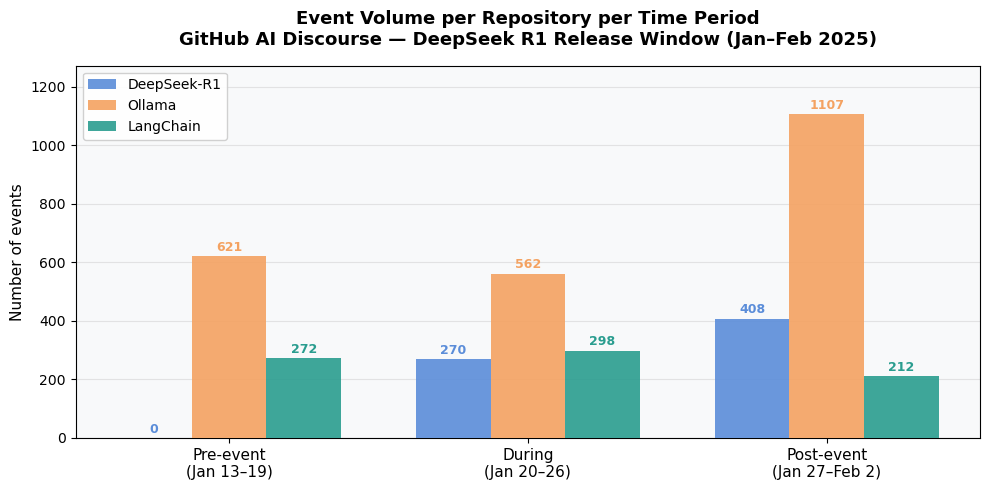

✓ Fig A1 saved: outputs/fig_a1_event_volume.png


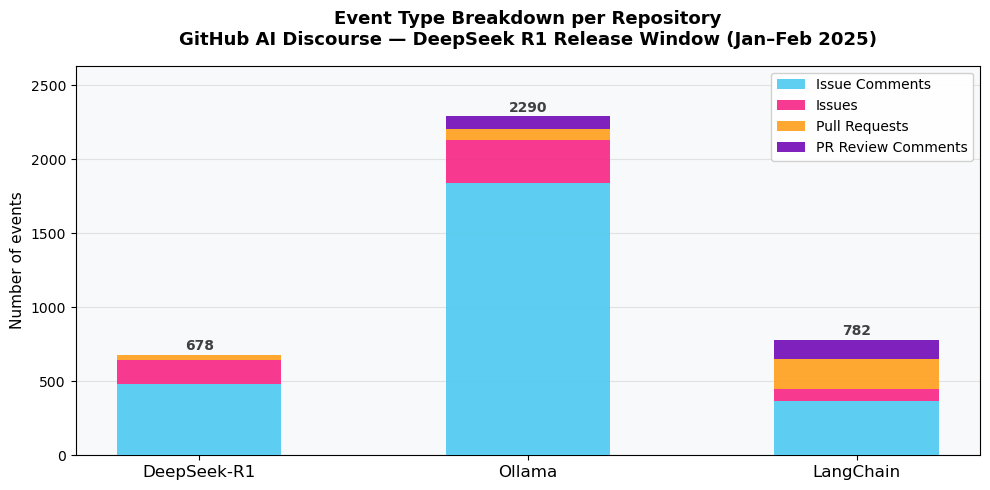

✓ Fig A2 saved: outputs/fig_a2_event_types.png


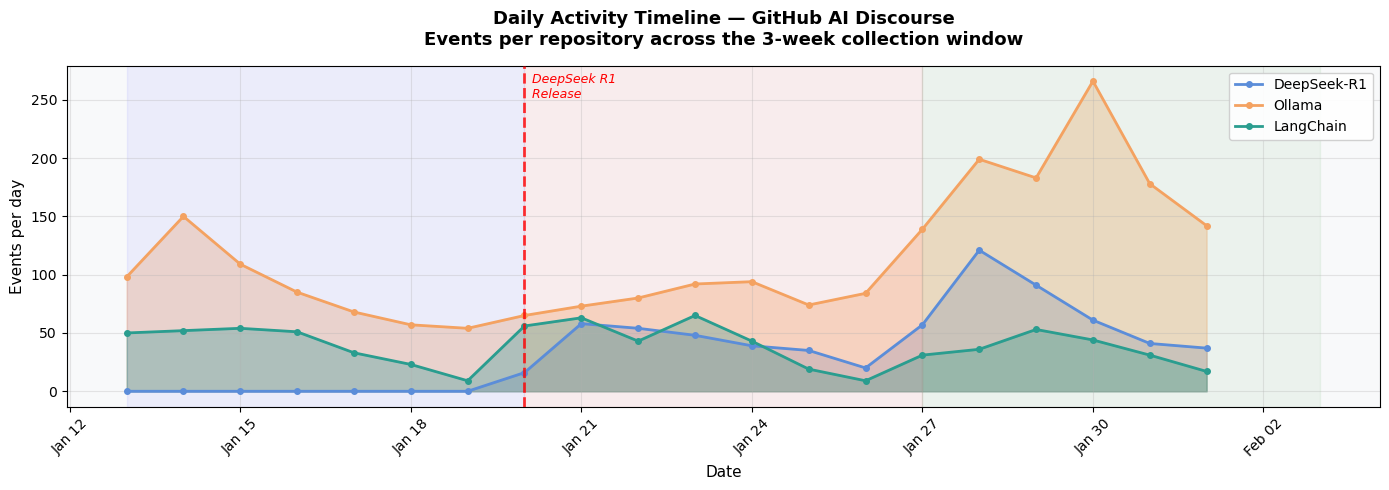

 Fig A3 saved: outputs/fig_a3_daily_timeline.png

  outputs/fig_a1_event_volume.png
  outputs/fig_a2_event_types.png
  outputs/fig_a3_daily_timeline.png


In [66]:

# Data Overview Visualisations
# ──────────────────────────────────────────────────────────────────────────
# Generates three visualisations summarising the collected dataset:
#   Fig A1 — Event volume per repository per time period
#   Fig A2 — Event type breakdown per repository
#   Fig A3 — Daily activity timeline across the 3-week window


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
import os

os.makedirs("outputs", exist_ok=True)

# ── Load data ─────────────────────────────────────────────────────────────
df = pd.read_csv("data/gh_api_full.csv")
df["created_at"] = pd.to_datetime(df["created_at"], utc=True)

# ── Period assignment ─────────────────────────────────────────────────────
def assign_period(dt):
    if dt < pd.Timestamp("2025-01-20", tz="UTC"):
        return "Pre-event\n(Jan 13–19)"
    elif dt < pd.Timestamp("2025-01-27", tz="UTC"):
        return "During\n(Jan 20–26)"
    else:
        return "Post-event\n(Jan 27–Feb 2)"

df["period"] = df["created_at"].apply(assign_period)

# ── Short repo labels ──────────────────────────────────────────────────────
REPO_LABELS = {
    "deepseek-ai/DeepSeek-R1": "DeepSeek-R1",
    "ollama/ollama"           : "Ollama",
    "langchain-ai/langchain"  : "LangChain"
}
df["repo_short"] = df["repo"].map(REPO_LABELS)

REPO_COLOURS = {
    "DeepSeek-R1": "#5B8DD9",
    "Ollama"     : "#F4A261",
    "LangChain"  : "#2A9D8F"
}

PERIOD_ORDER = ["Pre-event\n(Jan 13–19)",
                "During\n(Jan 20–26)",
                "Post-event\n(Jan 27–Feb 2)"]


# FIG A1 — Event volume per repo per period


fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("#f8f9fa")

period_repo = (df.groupby(["period", "repo_short"])
                 .size()
                 .unstack(fill_value=0)
                 .reindex(PERIOD_ORDER))

x     = np.arange(len(PERIOD_ORDER))
width = 0.25
repos = ["DeepSeek-R1", "Ollama", "LangChain"]

for i, repo in enumerate(repos):
    bars = ax.bar(
        x + i * width,
        period_repo[repo],
        width   = width,
        color   = REPO_COLOURS[repo],
        label   = repo,
        alpha   = 0.9,
        zorder  = 3
    )
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 8, str(int(h)),
            ha="center", va="bottom",
            fontsize=9, fontweight="bold",
            color=REPO_COLOURS[repo]
        )

ax.set_xticks(x + width)
ax.set_xticklabels(PERIOD_ORDER, fontsize=11)
ax.set_ylabel("Number of events", fontsize=11)
ax.set_title(
    "Event Volume per Repository per Time Period\n"
    "GitHub AI Discourse — DeepSeek R1 Release Window (Jan–Feb 2025)",
    fontsize=13, fontweight="bold", pad=15
)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(axis="y", alpha=0.3, zorder=1)
ax.set_ylim(0, max(period_repo.values.max(), 100) * 1.15)

plt.tight_layout()
plt.savefig("outputs/fig_a1_event_volume.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print(" Fig A1 saved: outputs/fig_a1_event_volume.png")


# FIG A2 — Event type breakdown per repository


EVENT_LABELS = {
    "IssueCommentEvent"             : "Issue Comments",
    "IssuesEvent"                   : "Issues",
    "PullRequestEvent"              : "Pull Requests",
    "PullRequestReviewCommentEvent" : "PR Review Comments"
}
EVENT_COLOURS = ["#4CC9F0", "#F72585", "#FF9F1C", "#7209B7"]

df["event_short"] = df["event_type"].map(EVENT_LABELS)

repo_event = (df.groupby(["repo_short", "event_short"])
                .size()
                .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("#f8f9fa")

event_types = list(EVENT_LABELS.values())
x           = np.arange(len(repos))
bottoms     = np.zeros(len(repos))

for i, etype in enumerate(event_types):
    if etype not in repo_event.columns:
        continue
    values = [repo_event.loc[r, etype] if r in repo_event.index else 0
              for r in repos]
    bars = ax.bar(
        x, values,
        bottom  = bottoms,
        color   = EVENT_COLOURS[i],
        label   = etype,
        alpha   = 0.9,
        zorder  = 3,
        width   = 0.5
    )
    bottoms += np.array(values)

# Annotate total on top of each bar
for xi, total in enumerate(bottoms):
    ax.text(xi, total + 10, str(int(total)),
            ha="center", va="bottom",
            fontsize=10, fontweight="bold", color="#404040")

ax.set_xticks(x)
ax.set_xticklabels(repos, fontsize=12)
ax.set_ylabel("Number of events", fontsize=11)
ax.set_title(
    "Event Type Breakdown per Repository\n"
    "GitHub AI Discourse — DeepSeek R1 Release Window (Jan–Feb 2025)",
    fontsize=13, fontweight="bold", pad=15
)
ax.legend(fontsize=10, framealpha=0.9, loc="upper right")
ax.grid(axis="y", alpha=0.3, zorder=1)
ax.set_ylim(0, bottoms.max() * 1.15)

plt.tight_layout()
plt.savefig("outputs/fig_a2_event_types.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print(" Fig A2 saved: outputs/fig_a2_event_types.png")


# FIG A3 — Daily activity timeline


df["date"]  = df["created_at"].dt.date
daily_total = (df.groupby(["date", "repo_short"])
                 .size()
                 .unstack(fill_value=0)
                 .reset_index())
daily_total["date"] = pd.to_datetime(daily_total["date"])

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("#f8f9fa")

for repo in repos:
    if repo not in daily_total.columns:
        continue
    ax.fill_between(
        daily_total["date"],
        daily_total[repo],
        alpha = 0.3,
        color = REPO_COLOURS[repo]
    )
    ax.plot(
        daily_total["date"],
        daily_total[repo],
        color     = REPO_COLOURS[repo],
        linewidth = 2,
        marker    = "o",
        markersize = 4,
        label     = repo,
        zorder    = 3
    )

# Release marker
ax.axvline(x=pd.Timestamp("2025-01-20"), color="red",
           linestyle="--", alpha=0.8, linewidth=2, zorder=4)
ax.text(pd.Timestamp("2025-01-20"), ax.get_ylim()[1] * 0.9,
        "  DeepSeek R1\n  Release",
        color="red", fontsize=9, style="italic", zorder=5)

# Period shading
ax.axvspan(pd.Timestamp("2025-01-13"), pd.Timestamp("2025-01-20"),
           alpha=0.05, color="blue", label="_nolegend_")
ax.axvspan(pd.Timestamp("2025-01-20"), pd.Timestamp("2025-01-27"),
           alpha=0.05, color="red", label="_nolegend_")
ax.axvspan(pd.Timestamp("2025-01-27"), pd.Timestamp("2025-02-03"),
           alpha=0.05, color="green", label="_nolegend_")

ax.set_ylabel("Events per day", fontsize=11)
ax.set_xlabel("Date", fontsize=11)
ax.set_title(
    "Daily Activity Timeline — GitHub AI Discourse\n"
    "Events per repository across the 3-week collection window",
    fontsize=13, fontweight="bold", pad=15
)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(alpha=0.3, zorder=1)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("outputs/fig_a3_daily_timeline.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print(" Fig A3 saved: outputs/fig_a3_daily_timeline.png")

# ── Summary ───────────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"{'='*55}")
print(f"  outputs/fig_a1_event_volume.png")
print(f"  outputs/fig_a2_event_types.png")
print(f"  outputs/fig_a3_daily_timeline.png")

## Network Construction

In [54]:

# Network Construction
# ──────────────────────────────────────────────────────────────────────────
# Constructs a two-layer network from the collected GitHub event data.
#
# Layer 1 — Co-participation network (undirected, weighted)
#   Nodes  : GitHub users
#   Edges  : two users connected if they commented on the same issue/PR
#   Weight : number of shared issues/PRs between two users
#   Purpose: captures broad community structure across all interaction types
#
# Layer 2 — PR reply network (directed, weighted)
#   Nodes  : GitHub users
#   Edges  : directed edge A→B when A directly replied to B's PR comment
#   Weight : reply frequency between two users
#   Purpose: captures explicit directed influence in PR review discussions
#
# Both layers are analysed separately — edge types have different
# meanings and are not mixed (co-participation ≠ direct reply)


import networkx as nx
from itertools import combinations
from collections import defaultdict

# ── Load validated dataset ────────────────────────────────────────────────
df = pd.read_csv("data/gh_api_full.csv")
df["created_at"] = pd.to_datetime(df["created_at"], utc=True)

# ── Remove ghost accounts ─────────────────────────────────────────────────
# ghost = GitHub placeholder for deleted user accounts — not real users
before = len(df)
df     = df[df["actor"] != "ghost"].copy()
print(f"Ghost accounts removed  : {before - len(df):,}")
print(f"Final dataset           : {len(df):,} events, "
      f"{df['actor'].nunique():,} unique users\n")


# LAYER 1 — Co-participation network (undirected, weighted)


print("Building Layer 1 — Co-participation network...")

# Group users by shared thread (repo + issue_number)
# Users who both comment on the same issue/PR are co-participants
thread_users = defaultdict(set)

for _, row in df.iterrows():
    if pd.notna(row["issue_number"]) and str(row["issue_number"]).strip():
        thread_id = f"{row['repo']}#{row['issue_number']}"
        thread_users[thread_id].add(row["actor"])

print(f"  Unique threads (issues/PRs) : {len(thread_users):,}")

# Build edge list — connect all pairs of users in same thread
co_edges     = defaultdict(int)
threads_used = 0

for thread_id, users in thread_users.items():
    users = list(users)
    if len(users) < 2:
        continue  # skip single-user threads — no edge possible
    threads_used += 1
    for u1, u2 in combinations(sorted(users), 2):
        co_edges[(u1, u2)] += 1  # weight = number of shared threads

print(f"  Threads with 2+ users       : {threads_used:,}")

# Build undirected weighted NetworkX graph
G1 = nx.Graph()
for (u1, u2), weight in co_edges.items():
    G1.add_edge(u1, u2, weight=weight)

# Add isolated users (appeared only in single-user threads)
for user in df["actor"].unique():
    if user not in G1:
        G1.add_node(user)

# Largest connected component for global analysis
largest_cc = max(nx.connected_components(G1), key=len)
G1_lcc     = G1.subgraph(largest_cc).copy()

print(f"\n   Layer 1 — Co-participation network:")
print(f"    Nodes (users)    : {G1.number_of_nodes():,}")
print(f"    Edges            : {G1.number_of_edges():,}")
print(f"    Directed         : No (undirected)")
print(f"    Weighted         : Yes (shared thread count)")
print(f"    Density          : {nx.density(G1):.4f}")
print(f"    Connected comps  : {nx.number_connected_components(G1):,}")
print(f"    Largest CC nodes : {G1_lcc.number_of_nodes():,}")
print(f"    Largest CC edges : {G1_lcc.number_of_edges():,}")


# LAYER 2 — PR reply network (directed, weighted)


print("\nBuilding Layer 2 — PR reply network...")

# Use temporal ordering within each PR thread to infer reply targets
# Edge: replier → most recent prior commenter in same PR thread
pr_all = (df[df["event_type"] == "PullRequestReviewCommentEvent"]
          .sort_values("created_at")
          .copy())

reply_edges    = defaultdict(int)
last_commenter = {}

for _, row in pr_all.iterrows():
    thread = f"{row['repo']}#{row['issue_number']}"
    actor  = row["actor"]

    if pd.notna(row["in_reply_to"]) and thread in last_commenter:
        target = last_commenter[thread]
        if target != actor:  # exclude self-loops
            reply_edges[(actor, target)] += 1

    last_commenter[thread] = actor

# Build directed weighted graph
G2 = nx.DiGraph()
for (src, tgt), weight in reply_edges.items():
    G2.add_edge(src, tgt, weight=weight)

# Weakly connected component stats
wcc    = max(nx.weakly_connected_components(G2), key=len) \
         if G2.number_of_nodes() > 0 else set()
G2_wcc = G2.subgraph(wcc).copy()

print(f"\n   Layer 2 — PR reply network:")
print(f"    Nodes (users)    : {G2.number_of_nodes():,}")
print(f"    Edges            : {G2.number_of_edges():,}")
print(f"    Directed         : Yes")
print(f"    Weighted         : Yes (reply frequency)")
print(f"    Density          : {nx.density(G2):.4f}")
print(f"    Weakly conn comps: {nx.number_weakly_connected_components(G2):,}")
print(f"    Largest WCC nodes: {G2_wcc.number_of_nodes():,}")
print(f"    Largest WCC edges: {G2_wcc.number_of_edges():,}")


# NETWORK SUMMARY


print(f"\n{'='*55}")
print(f"NETWORK CONSTRUCTION SUMMARY")
print(f"{'='*55}")
print(f"  Layer 1 (co-participation) : {G1.number_of_nodes():,} nodes, "
      f"{G1.number_of_edges():,} edges")
print(f"  Layer 2 (PR reply)         : {G2.number_of_nodes():,} nodes, "
      f"{G2.number_of_edges():,} edges")

# Top 10 most connected users — Layer 1
print(f"\nTop 10 most connected users (Layer 1 — degree):")
degree_sorted = sorted(G1.degree(), key=lambda x: x[1], reverse=True)[:10]
print(f"  {'Rank':<5} {'User':<30} {'Degree':>8}")
print(f"  {'-'*45}")
for i, (user, deg) in enumerate(degree_sorted, 1):
    print(f"  {i:<5} {user:<30} {deg:>8}")

# Top 10 most active repliers — Layer 2
print(f"\nTop 10 most active repliers (Layer 2 — out-degree):")
out_sorted = sorted(G2.out_degree(), key=lambda x: x[1], reverse=True)[:10]
print(f"  {'Rank':<5} {'User':<30} {'Out-degree':>10}")
print(f"  {'-'*48}")
for i, (user, deg) in enumerate(out_sorted, 1):
    print(f"  {i:<5} {user:<30} {deg:>10}")

print(f"\n Both network layers constructed — ready for centrality analysis")

Ghost accounts removed  : 18
Final dataset           : 3,732 events, 1,540 unique users

Building Layer 1 — Co-participation network...
  Unique threads (issues/PRs) : 1,315
  Threads with 2+ users       : 605

   Layer 1 — Co-participation network:
    Nodes (users)    : 1,540
    Edges            : 3,584
    Directed         : No (undirected)
    Weighted         : Yes (shared thread count)
    Density          : 0.0030
    Connected comps  : 474
    Largest CC nodes : 842
    Largest CC edges : 3,157

Building Layer 2 — PR reply network...

   Layer 2 — PR reply network:
    Nodes (users)    : 25
    Edges            : 34
    Directed         : Yes
    Weighted         : Yes (reply frequency)
    Density          : 0.0567
    Weakly conn comps: 2
    Largest WCC nodes: 18
    Largest WCC edges: 22

NETWORK CONSTRUCTION SUMMARY
  Layer 1 (co-participation) : 1,540 nodes, 3,584 edges
  Layer 2 (PR reply)         : 25 nodes, 34 edges

Top 10 most connected users (Layer 1 — degree):
  R

## Centrality Analysis

In [55]:

# Centrality Analysis
# ──────────────────────────────────────────────────────────────────────────
# Computes four centrality measures for every user in Layer 1 LCC:
#
#   Degree centrality  : proportion of users each node connects to
#   Strength           : total weighted interaction count
#   Betweenness        : fraction of shortest paths passing through a node
#                        identifies users who bridge separate communities
#   PageRank           : influence accounting for quality of connections
#                        not just quantity — standard alpha=0.85
#
# PageRank also computed on Layer 2 (directed) for comparison.
# All scores saved to data/centrality_scores.csv for downstream analysis.


# ── Work on largest connected component of Layer 1 ───────────────────────
# Global measures require a connected graph
# Isolated nodes have undefined betweenness and closeness centrality
largest_cc = max(nx.connected_components(G1), key=len)
G1_lcc     = G1.subgraph(largest_cc).copy()

print(f"Working on Layer 1 LCC:")
print(f"  Nodes : {G1_lcc.number_of_nodes():,}")
print(f"  Edges : {G1_lcc.number_of_edges():,}\n")

# ── Degree centrality ─────────────────────────────────────────────────────
# Normalised — proportion of all nodes each user is connected to
print("Computing degree centrality...")
degree_cent = nx.degree_centrality(G1_lcc)
print(f"   {len(degree_cent):,} users scored")

# ── Weighted degree (strength) ────────────────────────────────────────────
# Sum of edge weights — total co-participation interactions per user
print("Computing weighted degree (strength)...")
strength = dict(G1_lcc.degree(weight="weight"))
print(f"   {len(strength):,} users scored")

# ── Betweenness centrality ────────────────────────────────────────────────
# Fraction of shortest paths passing through each node
# High betweenness = user bridges otherwise disconnected communities
print("Computing betweenness centrality (may take 1-2 minutes)...")
between_cent = nx.betweenness_centrality(
    G1_lcc,
    weight     = "weight",
    normalized = True
)
print(f"   {len(between_cent):,} users scored")

# ── PageRank — Layer 1 (undirected) ──────────────────────────────────────
# Measures influence accounting for quality of connections
# Users cited by other high-influence users score higher
print("Computing PageRank on Layer 1...")
pagerank_l1 = nx.pagerank(G1_lcc, weight="weight", alpha=0.85)
print(f"   {len(pagerank_l1):,} users scored")

# ── PageRank — Layer 2 (directed) ────────────────────────────────────────
# Directed PageRank captures influence flow in PR reply network
# Complements Layer 1 by revealing PR-specific influence
print("Computing PageRank on Layer 2 (directed)...")
if G2.number_of_nodes() > 0:
    pagerank_l2 = nx.pagerank(G2, weight="weight", alpha=0.85)
    print(f"   {len(pagerank_l2):,} users scored")
else:
    pagerank_l2 = {}
    print(f"  ⚠ Layer 2 empty — skipping")

# ── Combine into centrality dataframe ────────────────────────────────────
centrality_df = pd.DataFrame({
    "user"        : list(degree_cent.keys()),
    "degree_cent" : list(degree_cent.values()),
    "strength"    : [strength.get(u, 0) for u in degree_cent.keys()],
    "betweenness" : [between_cent.get(u, 0) for u in degree_cent.keys()],
    "pagerank_l1" : [pagerank_l1.get(u, 0) for u in degree_cent.keys()],
    "pagerank_l2" : [pagerank_l2.get(u, 0) for u in degree_cent.keys()],
}).sort_values("pagerank_l1", ascending=False).reset_index(drop=True)

centrality_df.to_csv("data/centrality_scores.csv", index=False)

# ── Top 15 by PageRank ────────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"TOP 15 USERS BY PAGERANK — Layer 1")
print(f"{'='*70}")
print(f"{'Rank':<5} {'User':<30} {'PageRank':>10} "
      f"{'Betweenness':>12} {'Strength':>10} {'L2 PageRank':>12}")
print(f"  {'-'*68}")
for i, row in centrality_df.head(15).iterrows():
    print(f"  {i+1:<4} {row['user']:<30} {row['pagerank_l1']:>10.5f} "
          f"{row['betweenness']:>12.5f} {row['strength']:>10.0f} "
          f"{row['pagerank_l2']:>12.5f}")

# ── Top 10 by Betweenness ─────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"TOP 10 USERS BY BETWEENNESS — community bridges")
print(f"{'='*55}")
top_between = centrality_df.sort_values(
    "betweenness", ascending=False).head(10)
print(f"{'Rank':<5} {'User':<30} {'Betweenness':>12} {'PageRank':>10}")
print(f"  {'-'*55}")
for i, (_, row) in enumerate(top_between.iterrows(), 1):
    print(f"  {i:<4} {row['user']:<30} {row['betweenness']:>12.5f} "
          f"{row['pagerank_l1']:>10.5f}")

print(f"\n Centrality analysis complete")
print(f"  Saved to : data/centrality_scores.csv")
print(f"  Users    : {len(centrality_df):,}")

Working on Layer 1 LCC:
  Nodes : 842
  Edges : 3,157

Computing degree centrality...
   842 users scored
Computing weighted degree (strength)...
   842 users scored
Computing betweenness centrality (may take 1-2 minutes)...
   842 users scored
Computing PageRank on Layer 1...
   842 users scored
Computing PageRank on Layer 2 (directed)...
   25 users scored

TOP 15 USERS BY PAGERANK — Layer 1
Rank  User                             PageRank  Betweenness   Strength  L2 PageRank
  --------------------------------------------------------------------
  1    rick-github                       0.09389      0.80616        389      0.00000
  2    pdevine                           0.01487      0.08543         86      0.01393
  3    ccurme                            0.01470      0.14656         41      0.08413
  4    keenborder786                     0.00982      0.04112         22      0.00000
  5    efriis                            0.00962      0.04159         30      0.16390
  6    jmorganca 

## Community Detection

In [56]:

# Community Detection
# ──────────────────────────────────────────────────────────────────────────
# Applies two community detection algorithms on Layer 1 LCC:
#
#   Method A — Louvain  : standard modularity optimisation on undirected
#                         weighted graph. Well-established baseline.
#
#   Method B — Leiden   : improved Louvain that guarantees well-connected
#                         communities. Applied via leidenalg on igraph.
#                         Selected as primary method if modularity ≥ Louvain.
#
# Both methods compared by modularity score — best result selected.
# Community labels added to centrality dataframe for role classification.
# Repository distribution per community reveals whether communities
# align with repo ecosystems or cut across them.


import community as community_louvain
import leidenalg as la
import igraph as ig

# ── Method A — Louvain ────────────────────────────────────────────────────
print("Method A — Louvain community detection...")
louvain_partition   = community_louvain.best_partition(
    G1_lcc,
    weight       = "weight",
    random_state = 42
)
louvain_communities = len(set(louvain_partition.values()))
louvain_modularity  = community_louvain.modularity(
    louvain_partition, G1_lcc, weight="weight"
)
print(f"  Communities found : {louvain_communities}")
print(f"  Modularity score  : {louvain_modularity:.4f}")

# ── Method B — Leiden ─────────────────────────────────────────────────────
# Leiden requires igraph — convert NetworkX LCC to igraph format
print("\nMethod B — Leiden community detection...")

node_list  = list(G1_lcc.nodes())
node_index = {n: i for i, n in enumerate(node_list)}
edges_ig   = [(node_index[u], node_index[v]) for u, v in G1_lcc.edges()]
weights_ig = [G1_lcc[u][v]["weight"] for u, v in G1_lcc.edges()]

G1_ig           = ig.Graph(
    n        = len(node_list),
    edges    = edges_ig,
    directed = False
)
G1_ig.es["weight"] = weights_ig

leiden_result      = la.find_partition(
    G1_ig,
    la.ModularityVertexPartition,
    weights = "weight",
    seed    = 42
)
leiden_communities = len(leiden_result)
leiden_modularity  = leiden_result.modularity
print(f"  Communities found : {leiden_communities}")
print(f"  Modularity score  : {leiden_modularity:.4f}")

# ── Compare and select best method ───────────────────────────────────────
print(f"\n{'='*55}")
print(f"COMPARISON")
print(f"{'='*55}")
print(f"  Louvain : {louvain_communities} communities, "
      f"modularity {louvain_modularity:.4f}")
print(f"  Leiden  : {leiden_communities} communities, "
      f"modularity {leiden_modularity:.4f}")

best_method = "Leiden" if leiden_modularity >= louvain_modularity \
              else "Louvain"
print(f"\n  Selected : {best_method} "
      f"(modularity {max(leiden_modularity, louvain_modularity):.4f})")

# ── Assign community labels using best method ─────────────────────────────
if best_method == "Leiden":
    community_map = {
        node_list[i]: leiden_result.membership[i]
        for i in range(len(node_list))
    }
else:
    community_map = louvain_partition

# ── Add community labels to centrality dataframe ─────────────────────────
centrality_df["community"] = centrality_df["user"].map(community_map)
centrality_df.to_csv("data/centrality_scores.csv", index=False)

# ── Community size breakdown ──────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"COMMUNITY SIZE BREAKDOWN — {best_method}")
print(f"{'='*55}")
comm_sizes = (pd.Series(community_map)
                .value_counts()
                .sort_values(ascending=False))

for comm_id, size in comm_sizes.items():
    pct = size / len(community_map) * 100
    bar = "█" * int(pct / 2)
    print(f"  Community {comm_id:<3} : {size:>4} users  ({pct:>5.1f}%)  {bar}")

# ── Repository distribution per community ─────────────────────────────────
# Reveals whether communities align with repos or cut across them
print(f"\n{'='*55}")
print(f"REPOSITORY DISTRIBUTION PER COMMUNITY")
print(f"{'='*55}")

user_repo = (df.groupby("actor")["repo"]
               .agg(lambda x: x.value_counts().index[0])
               .to_dict())

comm_repo_df = pd.DataFrame({
    "user"      : list(community_map.keys()),
    "community" : list(community_map.values()),
    "repo"      : [user_repo.get(u, "unknown") for u in community_map.keys()]
})

repo_dist = (comm_repo_df
             .groupby(["community", "repo"])
             .size()
             .unstack(fill_value=0))
print(repo_dist.to_string())

print(f"\n Community detection complete")
print(f"  Best method  : {best_method}")
print(f"  Communities  : {len(comm_sizes)}")
print(f"  Modularity   : {max(leiden_modularity, louvain_modularity):.4f}")
print(f"  Saved to     : data/centrality_scores.csv")

Method A — Louvain community detection...
  Communities found : 20
  Modularity score  : 0.8321

Method B — Leiden community detection...
  Communities found : 21
  Modularity score  : 0.8440

COMPARISON
  Louvain : 20 communities, modularity 0.8321
  Leiden  : 21 communities, modularity 0.8440

  Selected : Leiden (modularity 0.8440)

COMMUNITY SIZE BREAKDOWN — Leiden
  Community 0   :  288 users  ( 34.2%)  █████████████████
  Community 1   :   75 users  (  8.9%)  ████
  Community 2   :   66 users  (  7.8%)  ███
  Community 3   :   59 users  (  7.0%)  ███
  Community 4   :   54 users  (  6.4%)  ███
  Community 5   :   51 users  (  6.1%)  ███
  Community 6   :   45 users  (  5.3%)  ██
  Community 7   :   36 users  (  4.3%)  ██
  Community 8   :   25 users  (  3.0%)  █
  Community 9   :   23 users  (  2.7%)  █
  Community 10  :   19 users  (  2.3%)  █
  Community 11  :   16 users  (  1.9%)  
  Community 12  :   15 users  (  1.8%)  
  Community 13  :   13 users  (  1.5%)  
  Community 14

## Role Classification

In [58]:

# Role Classification
# ──────────────────────────────────────────────────────────────────────────
# Classifies every user in the LCC into one of three structural roles
# based on their centrality scores:
#
#   Amplifier  : high PageRank — influential within their community
#                cited by other highly-cited users
#
#   Bridge     : high betweenness — connects otherwise separate communities
#                sits on shortest paths between community clusters
#                Bridge takes classification priority over Amplifier since
#                bridging behaviour is structurally rarer and more distinctive
#
#   Peripheral : low on both measures — occasional participant
#
# Thresholds set at 85th percentile — top 15% qualify per measure.
#
# Communities consolidated into 3 macro-groups by repository alignment
# based on the repository distribution table.


# ── Macro-community mapping ───────────────────────────────────────────────
# Consolidate 21 Leiden communities into 3 macro-groups by repo alignment
# Mapping based on repository distribution
ollama_communities    = [0, 2, 6, 7, 9, 10, 11, 15, 16, 19, 20]
langchain_communities = [1]
deepseek_communities  = [3, 4, 5, 8, 12, 13, 17, 18]
mixed_communities     = [14]  # cross-repo community

def assign_macro(comm_id):
    """Map Leiden community ID to macro repository group."""
    if comm_id in ollama_communities:
        return "ollama"
    elif comm_id in langchain_communities:
        return "langchain"
    elif comm_id in deepseek_communities:
        return "deepseek"
    elif comm_id in mixed_communities:
        return "mixed"
    else:
        return "unknown"

centrality_df["macro_community"] = centrality_df["community"].map(assign_macro)

# ── Role classification thresholds ───────────────────────────────────────
# 85th percentile — top 15% in each measure qualifies
pr_threshold = centrality_df["pagerank_l1"].quantile(0.85)
bt_threshold = centrality_df["betweenness"].quantile(0.85)

print(f"Classification thresholds (85th percentile):")
print(f"  PageRank threshold   : {pr_threshold:.5f}")
print(f"  Betweenness threshold: {bt_threshold:.5f}\n")

def classify_role(row):
    """
    Classify user into structural role based on centrality scores.
    Bridge priority: high betweenness overrides high PageRank since
    bridging is structurally rarer and more analytically significant.
    """
    high_pr = row["pagerank_l1"] >= pr_threshold
    high_bt = row["betweenness"] >= bt_threshold
    if high_bt:
        return "Bridge"
    elif high_pr:
        return "Amplifier"
    else:
        return "Peripheral"

centrality_df["role"] = centrality_df.apply(classify_role, axis=1)
centrality_df.to_csv("data/centrality_scores.csv", index=False)

# ── Role distribution ─────────────────────────────────────────────────────
print(f"{'='*55}")
print(f"ROLE DISTRIBUTION")
print(f"{'='*55}")
role_counts = centrality_df["role"].value_counts()
for role, count in role_counts.items():
    pct = count / len(centrality_df) * 100
    bar = "█" * int(pct / 2)
    print(f"  {role:<12} : {count:>4} users  ({pct:>5.1f}%)  {bar}")

# ── Role distribution by macro community ─────────────────────────────────
print(f"\n{'='*55}")
print(f"ROLE DISTRIBUTION BY MACRO COMMUNITY")
print(f"{'='*55}")
role_by_comm = (centrality_df
                .groupby(["macro_community", "role"])
                .size()
                .unstack(fill_value=0))
print(role_by_comm.to_string())

# ── Top Amplifiers ────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"TOP AMPLIFIERS — high PageRank, within-community influential")
print(f"{'='*55}")
amplifiers = (centrality_df[centrality_df["role"] == "Amplifier"]
              .sort_values("pagerank_l1", ascending=False)
              .head(10))
print(f"  {'Rank':<5} {'User':<28} {'PageRank':>10} "
      f"{'Community':>10} {'Macro':>12}")
print(f"  {'-'*68}")
for i, (_, row) in enumerate(amplifiers.iterrows(), 1):
    print(f"  {i:<5} {row['user']:<28} {row['pagerank_l1']:>10.5f} "
          f"{row['community']:>10.0f} {row['macro_community']:>12}")

# ── Top Bridges ───────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"TOP BRIDGES — high betweenness, cross-community connectors")
print(f"{'='*55}")
bridges = (centrality_df[centrality_df["role"] == "Bridge"]
           .sort_values("betweenness", ascending=False)
           .head(10))
print(f"  {'Rank':<5} {'User':<28} {'Betweenness':>12} "
      f"{'PageRank':>10} {'Macro':>12}")
print(f"  {'-'*70}")
for i, (_, row) in enumerate(bridges.iterrows(), 1):
    print(f"  {i:<5} {row['user']:<28} {row['betweenness']:>12.5f} "
          f"{row['pagerank_l1']:>10.5f} {row['macro_community']:>12}")

# ── Layer 2 influence ─────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"LAYER 2 INFLUENCE — PR review PageRank")
print(f"{'='*55}")
l2_users = (centrality_df[centrality_df["pagerank_l2"] > 0]
            .sort_values("pagerank_l2", ascending=False)
            .head(10))
print(f"  {'Rank':<5} {'User':<28} {'L2 PageRank':>12} "
      f"{'L1 Role':>12} {'Macro':>12}")
print(f"  {'-'*72}")
for i, (_, row) in enumerate(l2_users.iterrows(), 1):
    print(f"  {i:<5} {row['user']:<28} {row['pagerank_l2']:>12.5f} "
          f"{row['role']:>12} {row['macro_community']:>12}")

print(f"\n Role classification complete")
print(f"  Total users classified : {len(centrality_df):,}")
print(f"  Saved to               : data/centrality_scores.csv")

Classification thresholds (85th percentile):
  PageRank threshold   : 0.00159
  Betweenness threshold: 0.00188

ROLE DISTRIBUTION
  Peripheral   :  637 users  ( 75.7%)  █████████████████████████████████████
  Bridge       :  145 users  ( 17.2%)  ████████
  Amplifier    :   60 users  (  7.1%)  ███

ROLE DISTRIBUTION BY MACRO COMMUNITY
role             Amplifier  Bridge  Peripheral
macro_community                               
deepseek                20      35         180
langchain                1      10          64
mixed                    0       3           9
ollama                  39      97         384

TOP AMPLIFIERS — high PageRank, within-community influential
  Rank  User                           PageRank  Community        Macro
  --------------------------------------------------------------------
  1     cbornet                         0.00282          1    langchain
  2     ctx2002                         0.00242         11       ollama
  3     ChalsLapWork             

## Network visualisation

Building visualisation:
  Nodes in graph : 200
  Edges in graph : 1,599
Computing layout (may take 30 seconds)...


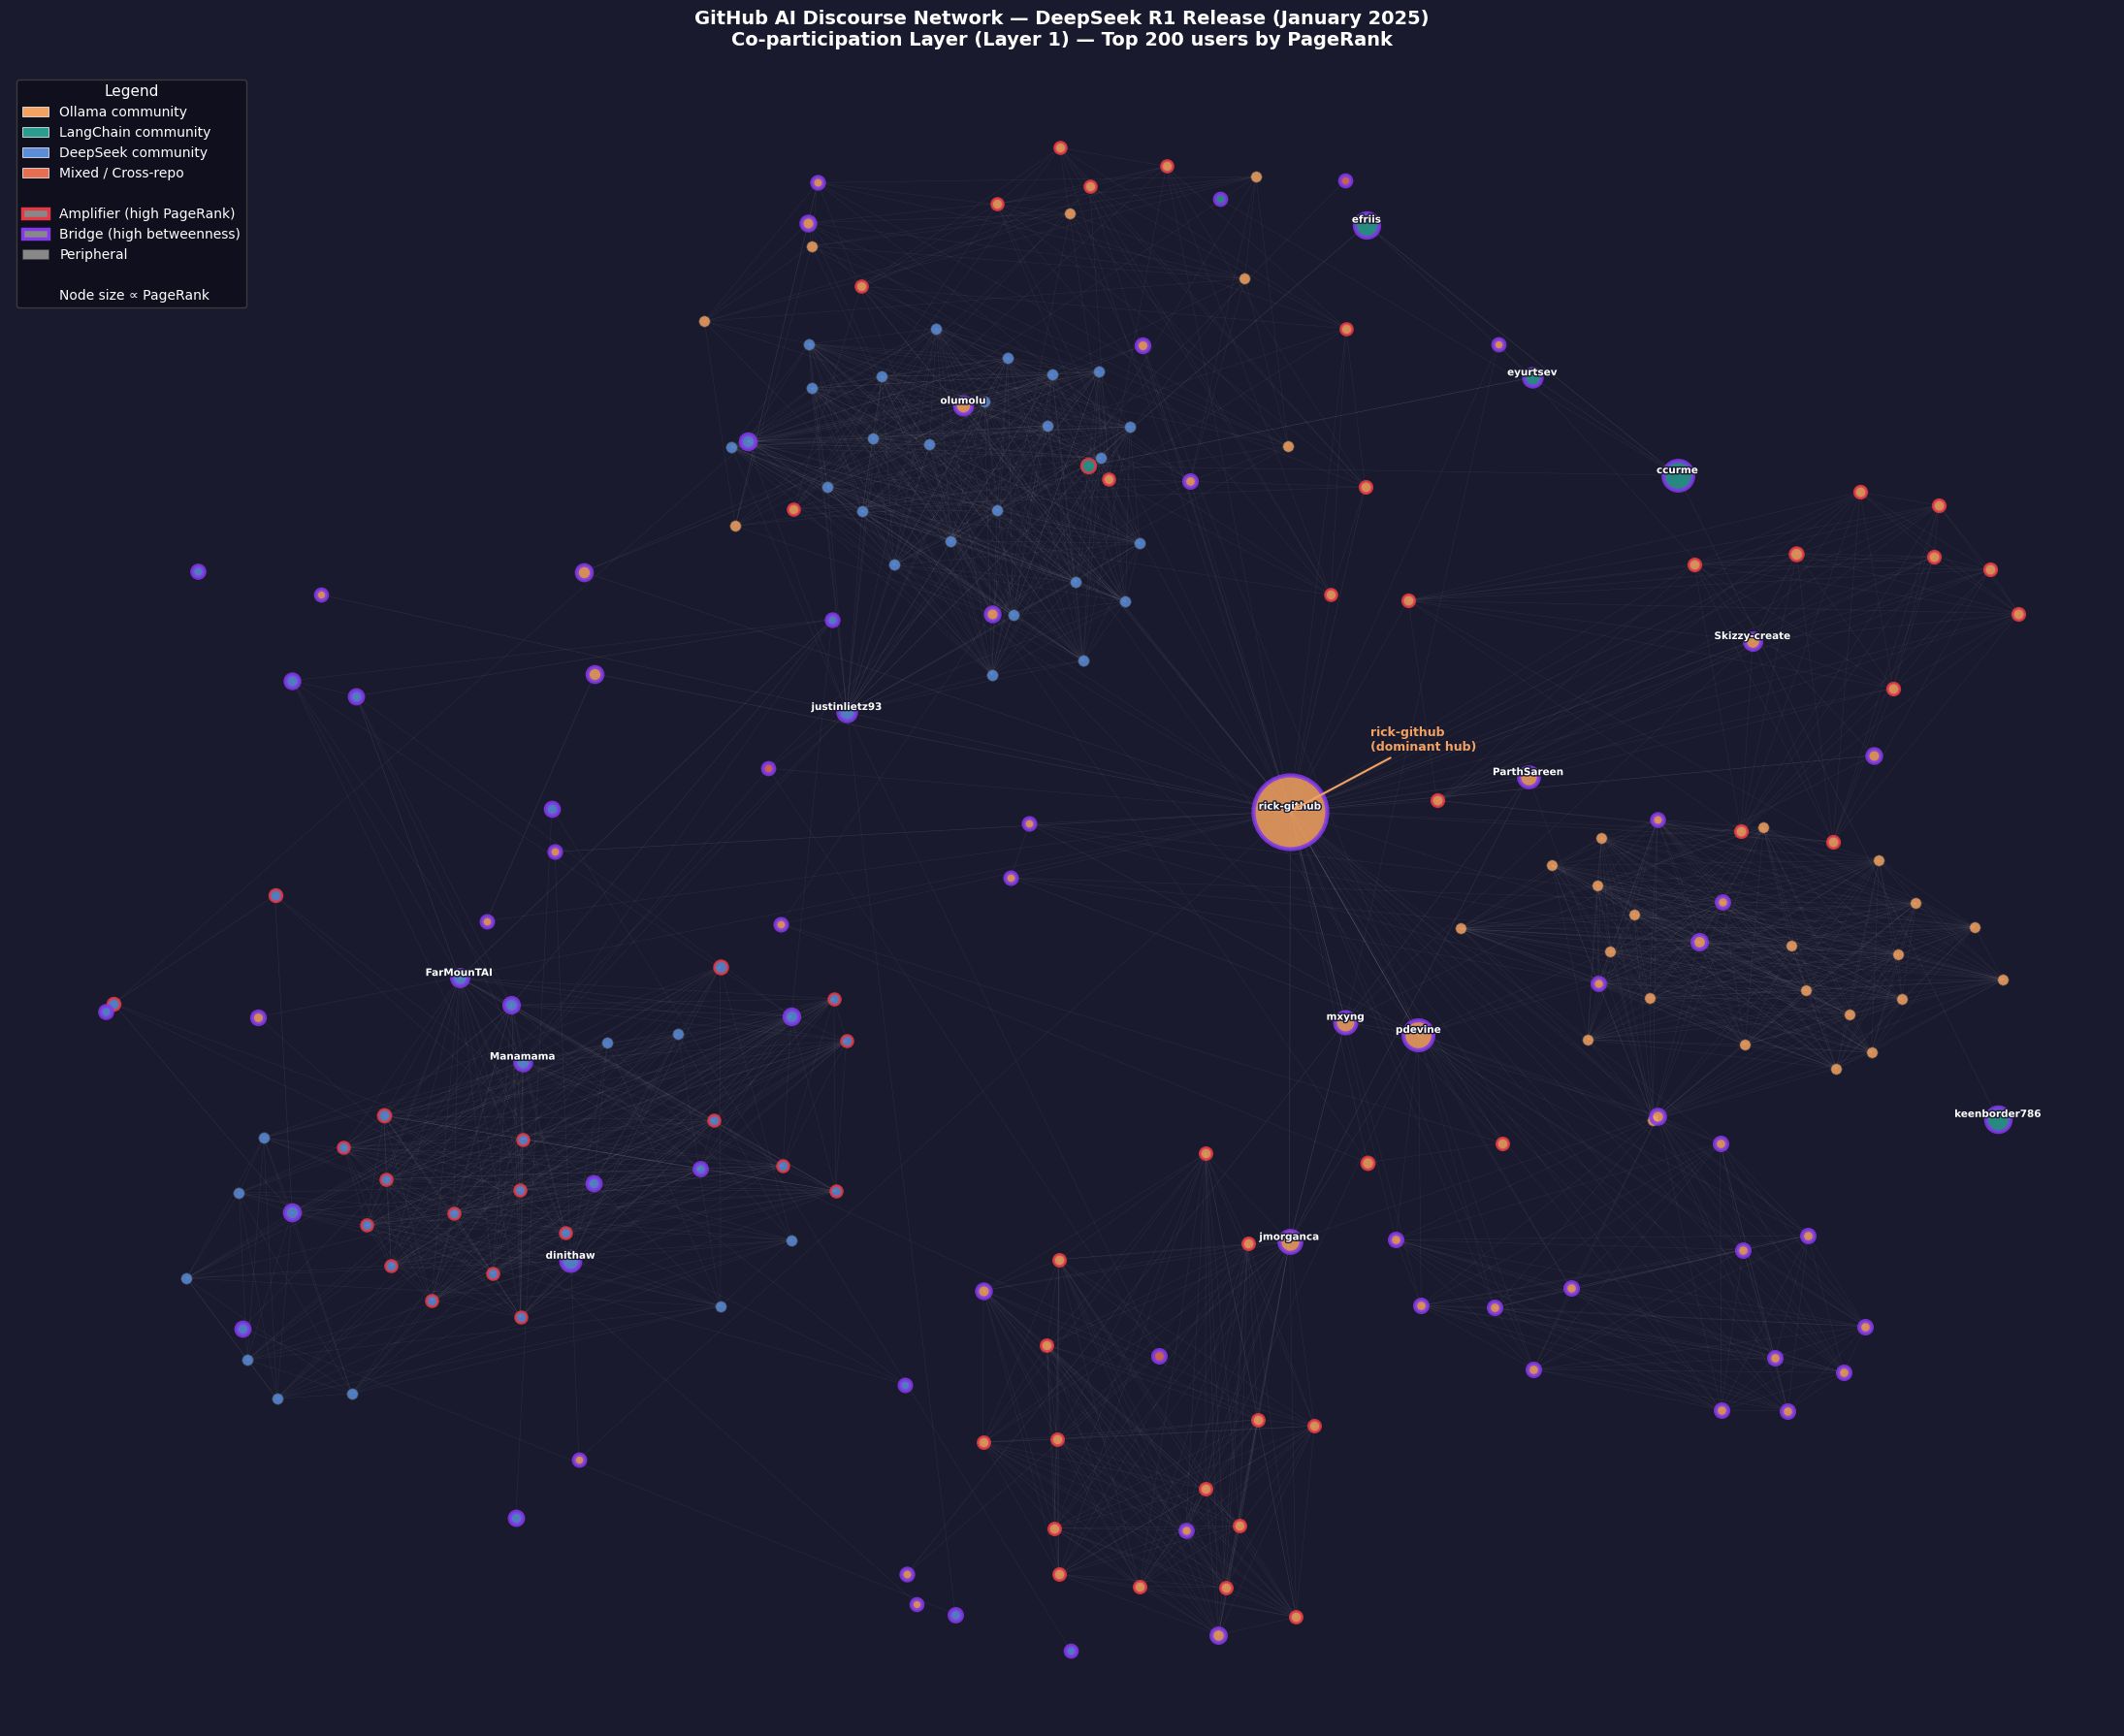


✓ Network visualisation saved to outputs/network_layer1.png
  Nodes shown : 200
  Edges shown : 1,599


In [59]:

# Network Visualisation
# ──────────────────────────────────────────────────────────────────────────
# Generates a publication-quality static network visualisation of
# Layer 1 (co-participation network) 
#
# Visual encoding:
#   Node size   : proportional to PageRank — larger = more influential
#   Node colour : macro community (repo alignment)
#                 Orange = Ollama, Teal = LangChain, Blue = DeepSeek
#                 Red-orange = Mixed/cross-repo
#   Border      : structural role
#                 Red = Amplifier, Purple = Bridge, Grey = Peripheral
#   Labels      : top 15 users by PageRank only — avoids overcrowding
#
# Filtered to top 200 nodes by PageRank + top 20 bridges for readability



import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

os.makedirs("outputs", exist_ok=True)

# ── Colour scheme ─────────────────────────────────────────────────────────
MACRO_COLOURS = {
    "ollama"   : "#F4A261",  # orange
    "langchain": "#2A9D8F",  # teal
    "deepseek" : "#5B8DD9",  # blue
    "mixed"    : "#E76F51",  # red-orange — cross-repo bridges
    "unknown"  : "#AAAAAA"   # grey
}

ROLE_BORDER = {
    "Amplifier" : "#E63946",  # red
    "Bridge"    : "#8338EC",  # purple
    "Peripheral": "#444444"   # dark grey
}

# ── Build user metadata lookup ────────────────────────────────────────────
user_meta = centrality_df.set_index("user").to_dict("index")

# ── Filter to top 200 nodes by PageRank + top 20 bridges ─────────────────
top_users   = set(centrality_df.head(200)["user"].tolist())
top_bridges = set(centrality_df[centrality_df["role"] == "Bridge"]
                  .head(20)["user"].tolist())
vis_users   = top_users | top_bridges
G1_vis      = G1_lcc.subgraph(vis_users).copy()

print(f"Building visualisation:")
print(f"  Nodes in graph : {G1_vis.number_of_nodes():,}")
print(f"  Edges in graph : {G1_vis.number_of_edges():,}")

# ── Compute spring layout ─────────────────────────────────────────────────
print("Computing layout (may take 30 seconds)...")
pos = nx.spring_layout(
    G1_vis,
    weight     = "weight",
    seed       = 42,
    k          = 1.2,
    iterations = 100
)

# ── Node properties ───────────────────────────────────────────────────────
node_list_vis  = list(G1_vis.nodes())
max_pr         = centrality_df["pagerank_l1"].max()
min_pr         = centrality_df["pagerank_l1"].min()

def scale_size(pr, min_size=30, max_size=3000):
    """Scale PageRank score to node size for visualisation."""
    if max_pr == min_pr:
        return min_size
    return min_size + (pr - min_pr) / (max_pr - min_pr) * (max_size - min_size)

node_colours   = []
node_sizes     = []
border_colours = []
border_widths  = []

for user in node_list_vis:
    meta  = user_meta.get(user, {})
    macro = meta.get("macro_community", "unknown")
    role  = meta.get("role", "Peripheral")
    pr    = meta.get("pagerank_l1", min_pr)
    node_colours.append(MACRO_COLOURS.get(macro, "#AAAAAA"))
    node_sizes.append(scale_size(pr))
    border_colours.append(ROLE_BORDER.get(role, "#444444"))
    border_widths.append(
        3.0 if role == "Bridge" else
        2.0 if role == "Amplifier" else
        0.5
    )

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 18))
ax.set_facecolor("#1a1a2e")
fig.patch.set_facecolor("#1a1a2e")

# Draw edges — thin and semi-transparent
edge_weights = [G1_vis[u][v]["weight"] for u, v in G1_vis.edges()]
max_w        = max(edge_weights) if edge_weights else 1

for (u, v), alpha in zip(
        G1_vis.edges(),
        [0.05 + 0.25 * (w / max_w) for w in edge_weights]):
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    ax.plot([x0, x1], [y0, y1],
            color="white", alpha=alpha, linewidth=0.4, zorder=1)

# Draw nodes in role order — peripheral first, bridges on top
for role_order in ["Peripheral", "Amplifier", "Bridge"]:
    for i, user in enumerate(node_list_vis):
        meta = user_meta.get(user, {})
        if meta.get("role", "Peripheral") != role_order:
            continue
        x, y = pos[user]
        ax.scatter(
            x, y,
            s          = node_sizes[i],
            c          = node_colours[i],
            edgecolors = border_colours[i],
            linewidths = border_widths[i],
            zorder     = 2 if role_order == "Peripheral" else
                         3 if role_order == "Amplifier" else 4,
            alpha      = 0.85
        )

# ── Labels — top 15 users + top 5 bridges ────────────────────────────────
top15         = set(centrality_df.head(15)["user"].tolist())
top5_bridges  = set(centrality_df[centrality_df["role"] == "Bridge"]
                    .head(5)["user"].tolist())
label_users   = top15 | top5_bridges

for user in node_list_vis:
    if user not in label_users:
        continue
    x, y = pos[user]
    ax.text(
        x, y, user,
        fontsize     = 7.5,
        color        = "white",
        fontweight   = "bold",
        ha           = "center",
        va           = "bottom",
        zorder       = 5,
        path_effects = [pe.withStroke(linewidth=2, foreground="#1a1a2e")]
    )

# ── Annotate dominant hub ─────────────────────────────────────────────────
if "rick-github" in pos:
    x, y = pos["rick-github"]
    ax.annotate(
        "rick-github\n(dominant hub)",
        xy         = (x, y),
        xytext     = (x + 0.08, y + 0.08),
        fontsize   = 9,
        color      = "#F4A261",
        fontweight = "bold",
        arrowprops = dict(arrowstyle="->", color="#F4A261", lw=1.5),
        zorder     = 6
    )

# ── Legend ────────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(facecolor="#F4A261", label="Ollama community",
                   edgecolor="white", linewidth=0.5),
    mpatches.Patch(facecolor="#2A9D8F", label="LangChain community",
                   edgecolor="white", linewidth=0.5),
    mpatches.Patch(facecolor="#5B8DD9", label="DeepSeek community",
                   edgecolor="white", linewidth=0.5),
    mpatches.Patch(facecolor="#E76F51", label="Mixed / Cross-repo",
                   edgecolor="white", linewidth=0.5),
    mpatches.Patch(facecolor="none",   edgecolor="none", label=" "),
    mpatches.Patch(facecolor="#888888", edgecolor="#E63946",
                   linewidth=2.5, label="Amplifier (high PageRank)"),
    mpatches.Patch(facecolor="#888888", edgecolor="#8338EC",
                   linewidth=2.5, label="Bridge (high betweenness)"),
    mpatches.Patch(facecolor="#888888", edgecolor="#444444",
                   linewidth=0.5, label="Peripheral"),
    mpatches.Patch(facecolor="none",   edgecolor="none", label=" "),
    mpatches.Patch(facecolor="none",   edgecolor="none",
                   label="Node size ∝ PageRank"),
]

legend = ax.legend(
    handles        = legend_elements,
    loc            = "upper left",
    fontsize       = 10,
    framealpha     = 0.8,
    facecolor      = "#0d0d1a",
    labelcolor     = "white",
    edgecolor      = "#444444",
    title          = "Legend",
    title_fontsize = 11
)
legend.get_title().set_color("white")

# ── Title ─────────────────────────────────────────────────────────────────
ax.set_title(
    "GitHub AI Discourse Network — DeepSeek R1 Release (January 2025)\n"
    "Co-participation Layer (Layer 1) — Top 200 users by PageRank",
    color      = "white",
    fontsize   = 14,
    pad        = 20,
    fontweight = "bold"
)
ax.axis("off")
plt.tight_layout()

# ── Save ──────────────────────────────────────────────────────────────────
plt.savefig(
    "outputs/network_layer1.png",
    dpi         = 150,
    bbox_inches = "tight",
    facecolor   = "#1a1a2e"
)
plt.show()

print(f"\n Network visualisation saved to outputs/network_layer1.png")
print(f"  Nodes shown : {G1_vis.number_of_nodes():,}")
print(f"  Edges shown : {G1_vis.number_of_edges():,}")

### Network Analysis Summary Visualisations

Generating Fig B1 — Degree distribution...


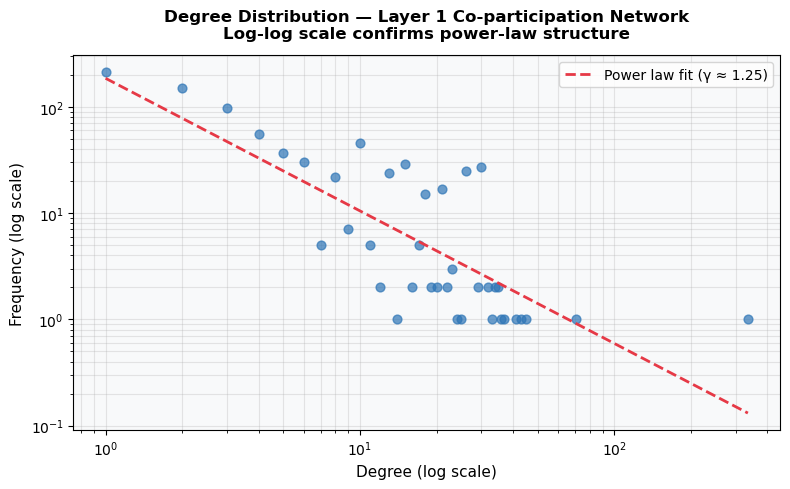

 Fig B1 saved: outputs/fig_b1_degree_distribution.png
Generating Fig B2 — Community size distribution...


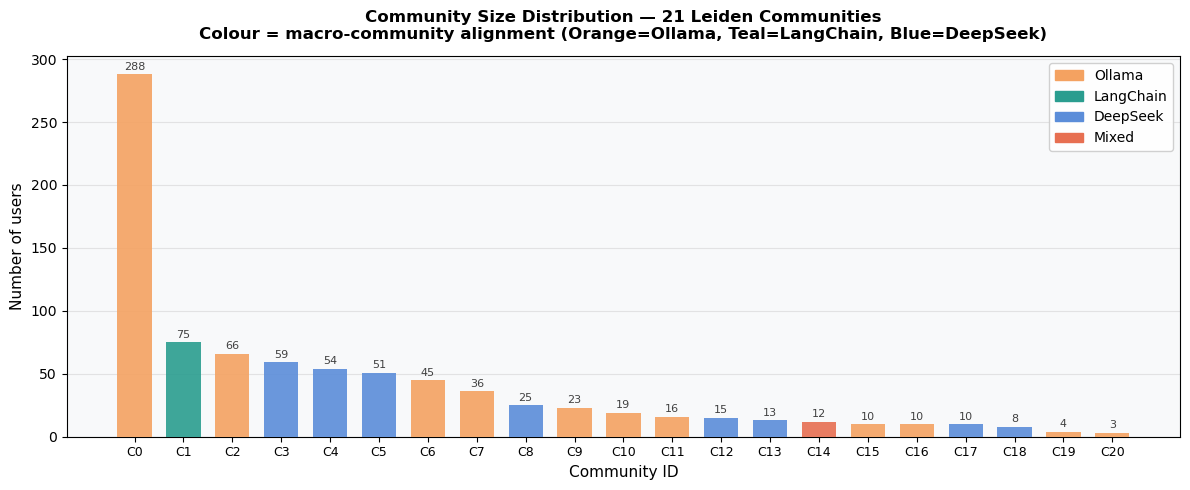

 Fig B2 saved: outputs/fig_b2_community_sizes.png
Generating Fig B3 — Role distribution...


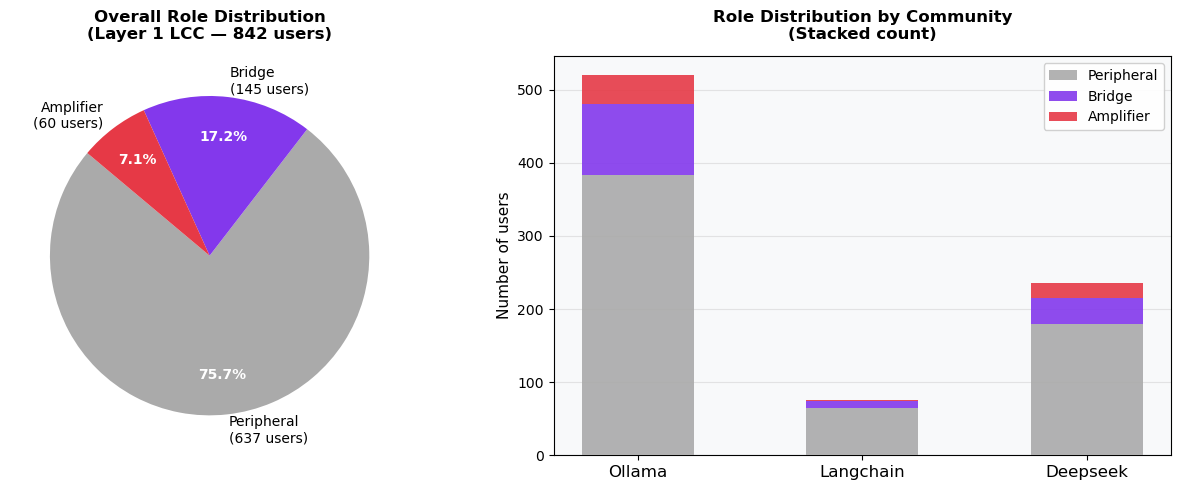

 Fig B3 saved: outputs/fig_b3_role_distribution.png
Generating Fig B4 — Top 10 users by PageRank...


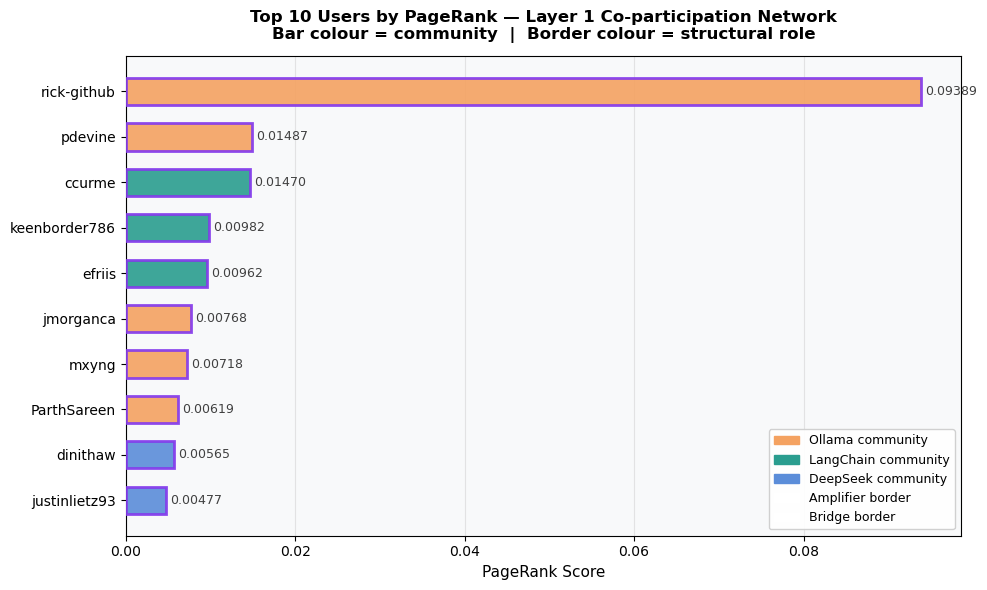

 Fig B4 saved: outputs/fig_b4_top10_pagerank.png
Generating Fig B5 — Algorithm comparison...


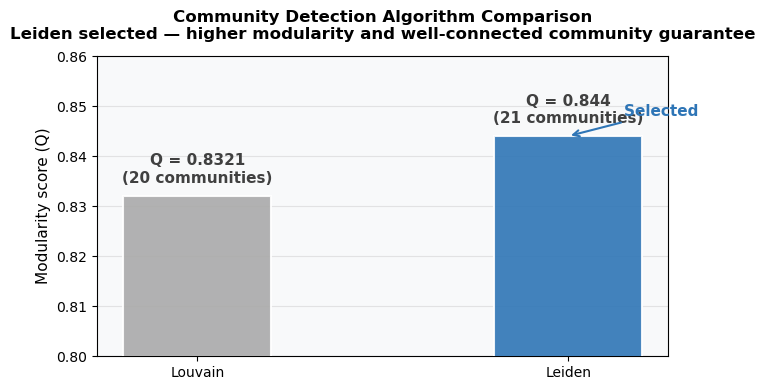

 Fig B5 saved: outputs/fig_b5_algorithm_comparison.png

  outputs/fig_b1_degree_distribution.png
  outputs/fig_b2_community_sizes.png
  outputs/fig_b3_role_distribution.png
  outputs/fig_b4_top10_pagerank.png
  outputs/fig_b5_algorithm_comparison.png


In [69]:

# Network Overview Visualisations
# ──────────────────────────────────────────────────────────────────────────
# Generates five visualisations summarising network analysis results:
#   Fig B1 — Degree distribution (log-log) — Layer 1
#   Fig B2 — Community size distribution — 21 Leiden communities
#   Fig B3 — Role distribution — Amplifier / Bridge / Peripheral
#   Fig B4 — Top 10 users by PageRank (horizontal bar)
#   Fig B5 — Louvain vs Leiden modularity comparison



import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import os
from collections import Counter

os.makedirs("outputs", exist_ok=True)

# ── Load centrality scores ────────────────────────────────────────────────
centrality_df = pd.read_csv("data/centrality_scores.csv")

ROLE_COLOURS = {
    "Amplifier" : "#E63946",
    "Bridge"    : "#8338EC",
    "Peripheral": "#AAAAAA"
}

MACRO_COLOURS = {
    "ollama"   : "#F4A261",
    "langchain": "#2A9D8F",
    "deepseek" : "#5B8DD9",
    "mixed"    : "#E76F51",
    "unknown"  : "#CCCCCC"
}


# FIG B1 — Degree distribution (log-log)


print("Generating Fig B1 — Degree distribution...")

degrees = [d for _, d in G1_lcc.degree()]
degree_counts = Counter(degrees)
deg_vals  = sorted(degree_counts.keys())
deg_freqs = [degree_counts[d] for d in deg_vals]

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("#f8f9fa")

ax.scatter(deg_vals, deg_freqs,
           color="#2E75B6", alpha=0.7, s=40, zorder=3)

# Fit power law line
log_deg  = np.log10([d for d in deg_vals if d > 0])
log_freq = np.log10([degree_counts[d] for d in deg_vals if d > 0])
if len(log_deg) > 2:
    coeffs   = np.polyfit(log_deg, log_freq, 1)
    fit_x    = np.linspace(min(log_deg), max(log_deg), 100)
    fit_y    = np.polyval(coeffs, fit_x)
    ax.plot(10**fit_x, 10**fit_y,
            color="#E63946", linewidth=2,
            linestyle="--", label=f"Power law fit (γ ≈ {abs(coeffs[0]):.2f})",
            zorder=4)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Degree (log scale)", fontsize=11)
ax.set_ylabel("Frequency (log scale)", fontsize=11)
ax.set_title(
    "Degree Distribution — Layer 1 Co-participation Network\n"
    "Log-log scale confirms power-law structure",
    fontsize=12, fontweight="bold", pad=12
)
ax.legend(fontsize=10)
ax.grid(alpha=0.3, which="both", zorder=1)

plt.tight_layout()
plt.savefig("outputs/fig_b1_degree_distribution.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print(" Fig B1 saved: outputs/fig_b1_degree_distribution.png")


# FIG B2 — Community size distribution


print("Generating Fig B2 — Community size distribution...")

comm_sizes = (centrality_df.groupby("community")
                            .size()
                            .sort_values(ascending=False)
                            .reset_index())
comm_sizes.columns = ["community", "size"]

# Colour bars by macro community
comm_macro = (centrality_df.groupby("community")["macro_community"]
                            .agg(lambda x: x.value_counts().index[0])
                            .to_dict())
bar_colours = [MACRO_COLOURS.get(comm_macro.get(c, "unknown"), "#CCCCCC")
               for c in comm_sizes["community"]]

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("#f8f9fa")

bars = ax.bar(
    range(len(comm_sizes)),
    comm_sizes["size"],
    color  = bar_colours,
    alpha  = 0.9,
    zorder = 3,
    width  = 0.7
)

for i, (bar, row) in enumerate(zip(bars, comm_sizes.itertuples())):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2,
            str(int(row.size)),
            ha="center", va="bottom",
            fontsize=8, color="#404040")

ax.set_xticks(range(len(comm_sizes)))
ax.set_xticklabels(
    [f"C{int(c)}" for c in comm_sizes["community"]],
    fontsize=9
)
ax.set_xlabel("Community ID", fontsize=11)
ax.set_ylabel("Number of users", fontsize=11)
ax.set_title(
    "Community Size Distribution — 21 Leiden Communities\n"
    "Colour = macro-community alignment (Orange=Ollama, Teal=LangChain, Blue=DeepSeek)",
    fontsize=12, fontweight="bold", pad=12
)

legend_patches = [
    mpatches.Patch(color="#F4A261", label="Ollama"),
    mpatches.Patch(color="#2A9D8F", label="LangChain"),
    mpatches.Patch(color="#5B8DD9", label="DeepSeek"),
    mpatches.Patch(color="#E76F51", label="Mixed"),
]
ax.legend(handles=legend_patches, fontsize=10, framealpha=0.9)
ax.grid(axis="y", alpha=0.3, zorder=1)

plt.tight_layout()
plt.savefig("outputs/fig_b2_community_sizes.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print(" Fig B2 saved: outputs/fig_b2_community_sizes.png")


# FIG B3 — Role distribution (pie + stacked bar by macro community)


print("Generating Fig B3 — Role distribution...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("white")

# Left — pie chart overall
role_counts = centrality_df["role"].value_counts()
role_order  = ["Peripheral", "Bridge", "Amplifier"]
role_vals   = [role_counts.get(r, 0) for r in role_order]
role_cols   = [ROLE_COLOURS[r] for r in role_order]

wedges, texts, autotexts = ax1.pie(
    role_vals,
    labels    = [f"{r}\n({v:,} users)" for r, v in zip(role_order, role_vals)],
    colors    = role_cols,
    autopct   = "%1.1f%%",
    startangle = 140,
    pctdistance = 0.75,
    textprops  = {"fontsize": 10}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight("bold")
    at.set_color("white")

ax1.set_title("Overall Role Distribution\n(Layer 1 LCC — 842 users)",
              fontsize=12, fontweight="bold", pad=12)

# Right — stacked bar by macro community
macros     = ["ollama", "langchain", "deepseek"]
macro_role = (centrality_df[centrality_df["macro_community"].isin(macros)]
              .groupby(["macro_community", "role"])
              .size()
              .unstack(fill_value=0))

x       = np.arange(len(macros))
bottoms = np.zeros(len(macros))

for role in role_order:
    if role not in macro_role.columns:
        continue
    vals = [macro_role.loc[m, role] if m in macro_role.index else 0
            for m in macros]
    ax2.bar(x, vals, bottom=bottoms,
            color=ROLE_COLOURS[role], label=role,
            alpha=0.9, zorder=3, width=0.5)
    bottoms += np.array(vals)

ax2.set_xticks(x)
ax2.set_xticklabels([m.capitalize() for m in macros], fontsize=12)
ax2.set_ylabel("Number of users", fontsize=11)
ax2.set_title("Role Distribution by Community\n(Stacked count)",
              fontsize=12, fontweight="bold", pad=12)
ax2.legend(fontsize=10, framealpha=0.9)
ax2.grid(axis="y", alpha=0.3, zorder=1)
ax2.set_facecolor("#f8f9fa")

plt.tight_layout()
plt.savefig("outputs/fig_b3_role_distribution.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print(" Fig B3 saved: outputs/fig_b3_role_distribution.png")


# FIG B4 — Top 10 users by PageRank (horizontal bar)


print("Generating Fig B4 — Top 10 users by PageRank...")

top10 = centrality_df.head(10).copy()
top10 = top10.sort_values("pagerank_l1")

bar_cols = [MACRO_COLOURS.get(m, "#CCCCCC")
            for m in top10["macro_community"]]
border_cols = [ROLE_COLOURS.get(r, "#CCCCCC")
               for r in top10["role"]]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("#f8f9fa")

bars = ax.barh(
    top10["user"],
    top10["pagerank_l1"],
    color      = bar_cols,
    edgecolor  = border_cols,
    linewidth  = 2,
    alpha      = 0.9,
    zorder     = 3,
    height     = 0.6
)

for bar, val in zip(bars, top10["pagerank_l1"]):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height() / 2,
            f"{val:.5f}",
            va="center", fontsize=9, color="#404040")

ax.set_xlabel("PageRank Score", fontsize=11)
ax.set_title(
    "Top 10 Users by PageRank — Layer 1 Co-participation Network\n"
    "Bar colour = community  |  Border colour = structural role",
    fontsize=12, fontweight="bold", pad=12
)

legend_patches = [
    mpatches.Patch(color="#F4A261", label="Ollama community"),
    mpatches.Patch(color="#2A9D8F", label="LangChain community"),
    mpatches.Patch(color="#5B8DD9", label="DeepSeek community"),
    mpatches.Patch(color="white", edgecolor="#E63946",
                   linewidth=2, label="Amplifier border"),
    mpatches.Patch(color="white", edgecolor="#8338EC",
                   linewidth=2, label="Bridge border"),
]
ax.legend(handles=legend_patches, fontsize=9,
          framealpha=0.9, loc="lower right")
ax.grid(axis="x", alpha=0.3, zorder=1)

plt.tight_layout()
plt.savefig("outputs/fig_b4_top10_pagerank.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print(" Fig B4 saved: outputs/fig_b4_top10_pagerank.png")


# FIG B5 — Louvain vs Leiden modularity comparison


print("Generating Fig B5 — Algorithm comparison...")

fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor("white")
ax.set_facecolor("#f8f9fa")

algorithms   = ["Louvain", "Leiden"]
modularities = [0.8321, 0.8440]
communities  = [20, 21]
colours      = ["#AAAAAA", "#2E75B6"]

bars = ax.bar(algorithms, modularities,
              color=colours, width=0.4,
              alpha=0.9, zorder=3,
              edgecolor="white", linewidth=1.5)

for bar, mod, comm in zip(bars, modularities, communities):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f"Q = {mod}\n({comm} communities)",
            ha="center", va="bottom",
            fontsize=11, fontweight="bold",
            color="#404040")

ax.set_ylabel("Modularity score (Q)", fontsize=11)
ax.set_ylim(0.80, 0.86)
ax.set_title(
    "Community Detection Algorithm Comparison\n"
    "Leiden selected — higher modularity and well-connected community guarantee",
    fontsize=12, fontweight="bold", pad=12
)
ax.grid(axis="y", alpha=0.3, zorder=1)

# Arrow annotation
ax.annotate("Selected ",
            xy     = (1, 0.8440),
            xytext = (1.15, 0.848),
            fontsize = 11,
            color    = "#2E75B6",
            fontweight = "bold",
            arrowprops = dict(arrowstyle="->",
                              color="#2E75B6", lw=1.5))

plt.tight_layout()
plt.savefig("outputs/fig_b5_algorithm_comparison.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print(" Fig B5 saved: outputs/fig_b5_algorithm_comparison.png")

# ── Summary ───────────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  outputs/fig_b1_degree_distribution.png")
print(f"  outputs/fig_b2_community_sizes.png")
print(f"  outputs/fig_b3_role_distribution.png")
print(f"  outputs/fig_b4_top10_pagerank.png")
print(f"  outputs/fig_b5_algorithm_comparison.png")

## Topic Modelling (BERTopic)

In [60]:

# Topic Modelling (BERTopic)
# ──────────────────────────────────────────────────────────────────────────
# Applies BERTopic to identify latent themes across GitHub issue and
# PR comment text. BERTopic is chosen over LDA because it uses
# contextual sentence embeddings (sentence-transformers) rather than
# bag-of-words, making it more suitable for short technical GitHub
# comments where word order and context carry meaning.
#
# Topics extracted across:
#   - Overall corpus
#   - Per macro community (ollama / langchain / deepseek)
#   - Per time period (pre / during / post DeepSeek R1 release)
#
# Topic modelling is the primary NLP approach 
# GitHub discussions contain high technical keyword frequency which
# causes systematic negative bias in raw sentiment scoring.


from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

# ── Prepare text corpus ───────────────────────────────────────────────────
# Use IssueCommentEvent and PullRequestReviewCommentEvent only
# These contain the richest discussion text
text_df = df[
    (df["event_type"].isin([
        "IssueCommentEvent",
        "PullRequestReviewCommentEvent"
    ])) &
    (df["text"].str.len() > 50)  # exclude very short comments
].copy()

# ── Assign period labels ──────────────────────────────────────────────────
def assign_period(dt):
    """Assign pre/during/post label based on DeepSeek R1 release date."""
    if dt < pd.Timestamp("2025-01-20", tz="UTC"):
        return "pre"
    elif dt < pd.Timestamp("2025-01-27", tz="UTC"):
        return "during"
    else:
        return "post"

text_df["period"] = text_df["created_at"].apply(assign_period)

# ── Map macro community from centrality dataframe ─────────────────────────
user_macro       = centrality_df.set_index("user")["macro_community"].to_dict()
text_df["macro"] = text_df["actor"].map(user_macro).fillna("unknown")

print(f"Text corpus prepared:")
print(f"  Total documents  : {len(text_df):,}")
print(f"  Mean text length : {text_df['text'].str.len().mean():.0f} chars")
print(f"\nPeriod breakdown:")
print(text_df["period"].value_counts().reindex(
      ["pre","during","post"]).to_string())
print(f"\nMacro community breakdown:")
print(text_df["macro"].value_counts().to_string())

# ── Initialise BERTopic ───────────────────────────────────────────────────
# Custom vectorizer removes common English stop words
# Bigrams included to capture technical phrase patterns
# min_df=2 ensures topics are supported by multiple documents
print(f"\nInitialising BERTopic...")

vectorizer = CountVectorizer(
    stop_words  = "english",
    ngram_range = (1, 2),
    min_df      = 2
)

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

topic_model = BERTopic(
    embedding_model = embedding_model,
    vectorizer_model = vectorizer,
    nr_topics        = "auto",  # algorithm determines optimal number
    min_topic_size   = 10,      # minimum 10 documents per topic
    verbose          = True
)

# ── Fit model ─────────────────────────────────────────────────────────────
docs = text_df["text"].tolist()
print(f"\nFitting BERTopic on {len(docs):,} documents...")
print(f"(This may take 3-5 minutes on first run)\n")

topics, probs = topic_model.fit_transform(docs)

text_df["topic"]      = topics
text_df["topic_prob"] = probs

# ── Topic overview ────────────────────────────────────────────────────────
topic_info = topic_model.get_topic_info()

print(f"\n{'='*65}")
print(f"TOPIC OVERVIEW")
print(f"{'='*65}")
print(f"  Total topics found  : {len(topic_info) - 1}")
print(f"  Outlier documents   : {(text_df['topic'] == -1).sum():,}")
print(f"\nTop 15 topics by document count:")
print(f"  {'Topic':<8} {'Size':>6}  Top Keywords")
print(f"  {'-'*65}")
for _, row in topic_info[topic_info["Topic"] != -1].head(15).iterrows():
    tid      = row["Topic"]
    size     = row["Count"]
    words    = topic_model.get_topic(tid)
    keywords = ", ".join([w for w, _ in words[:6]])
    print(f"  {tid:<8} {size:>6}   {keywords}")

# ── Topic distribution per macro community ────────────────────────────────
text_no_outlier = text_df[text_df["topic"] != -1]

print(f"\n{'='*65}")
print(f"TOP 5 TOPICS PER MACRO COMMUNITY")
print(f"{'='*65}")

topic_comm = (text_no_outlier
              .groupby(["macro","topic"])
              .size()
              .unstack(fill_value=0))

for macro in ["ollama","langchain","deepseek"]:
    if macro in topic_comm.index:
        top_topics = topic_comm.loc[macro].nlargest(5)
        print(f"\n  {macro.upper()}:")
        for tid, count in top_topics.items():
            words    = topic_model.get_topic(tid)
            keywords = ", ".join([w for w, _ in words[:4]])
            print(f"    Topic {tid:<4}: {count:>4} docs — {keywords}")

# ── Topic distribution per time period ───────────────────────────────────
print(f"\n{'='*65}")
print(f"TOP 5 TOPICS PER TIME PERIOD")
print(f"{'='*65}")

topic_period = (text_no_outlier
                .groupby(["period","topic"])
                .size()
                .unstack(fill_value=0))

for period in ["pre","during","post"]:
    if period in topic_period.index:
        top_topics = topic_period.loc[period].nlargest(5)
        print(f"\n  {period.upper()}-EVENT:")
        for tid, count in top_topics.items():
            words    = topic_model.get_topic(tid)
            keywords = ", ".join([w for w, _ in words[:4]])
            print(f"    Topic {tid:<4}: {count:>4} docs — {keywords}")

# ── Save ──────────────────────────────────────────────────────────────────
text_df.to_csv("data/text_with_topics.csv", index=False)
topic_info.to_csv("data/topic_info.csv", index=False)

print(f"\n BERTopic complete")
print(f"  Topics found : {len(topic_info) - 1}")
print(f"  Saved to     : data/text_with_topics.csv")
print(f"  Topic info   : data/topic_info.csv")

Text corpus prepared:
  Total documents  : 2,385
  Mean text length : 370 chars

Period breakdown:
period
pre        580
during     710
post      1095

Macro community breakdown:
macro
ollama       1325
unknown       566
deepseek      261
langchain     218
mixed          15

Initialising BERTopic...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

2026-05-21 00:44:41,689 - BERTopic - Embedding - Transforming documents to embeddings.



Fitting BERTopic on 2,385 documents...
(This may take 3-5 minutes on first run)



Batches:   0%|          | 0/75 [00:00<?, ?it/s]

2026-05-21 00:45:39,387 - BERTopic - Embedding - Completed ✓
2026-05-21 00:45:39,389 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-21 00:45:53,217 - BERTopic - Dimensionality - Completed ✓
2026-05-21 00:45:53,219 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-21 00:45:53,384 - BERTopic - Cluster - Completed ✓
2026-05-21 00:45:53,386 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-21 00:45:54,138 - BERTopic - Representation - Completed ✓
2026-05-21 00:45:54,140 - BERTopic - Topic reduction - Reducing number of topics
2026-05-21 00:45:54,166 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-21 00:45:54,550 - BERTopic - Representation - Completed ✓
2026-05-21 00:45:54,553 - BERTopic - Topic reduction - Reduced number of topics from 39 to 16



TOPIC OVERVIEW
  Total topics found  : 15
  Outlier documents   : 865

Top 15 topics by document count:
  Topic      Size  Top Keywords
  -----------------------------------------------------------------
  0           564   ollama, https, ollama ollama, com, github, github com
  1           252   pr, issue, thanks, just, new, thank
  2           156   langchain, issue, dosu, latest version, version, version langchain
  3           145   deepseek, r1, deepseek r1, https, deepseek ai, com
  4            92   censorship, china, chinese, ai, like, politics
  5            80   content, role, messages, assistant, tools, user
  6            67   download, process, pull, speed, write, 10
  7            25   dns, dns server, click, network, settings, properties
  8            24   ggml, backend, build, makefile, ggml src, ml
  9            23   image, attachments assets, assets, com user, attachments, user attachments
  10           19   action, answer, thought, final, input, think
  11       

## Sentiment Analysis (Supplementary)

Scoring sentiment on cleaned text...
   2,385 documents scored

SENTIMENT DISTRIBUTION BY PERIOD
sentiment_label  Negative  Neutral  Positive
period                                      
pre                    99      152       329
during                115      197       398
post                  182      332       581

Mean sentiment score by period:
  pre      :  0.2496  ↑ Positive
  during   :  0.2522  ↑ Positive
  post     :  0.2309  ↑ Positive

STATISTICAL SIGNIFICANCE TESTS

Kruskal-Wallis — sentiment across periods:
  H-statistic : 2.1625
  p-value     : 0.3392
  Result      :  No significant difference (p≥0.05)
  Interpretation: sentiment stability is itself a finding —
  topic framing changed dramatically while emotional tone
  remained consistent across the release window

Kruskal-Wallis — sentiment across communities:
  H-statistic : 3.9298
  p-value     : 0.1402
  Result      :  No significant difference (p≥0.05)

MEAN SENTIMENT BY COMMUNITY
  deepseek     : mean= 0.2004  

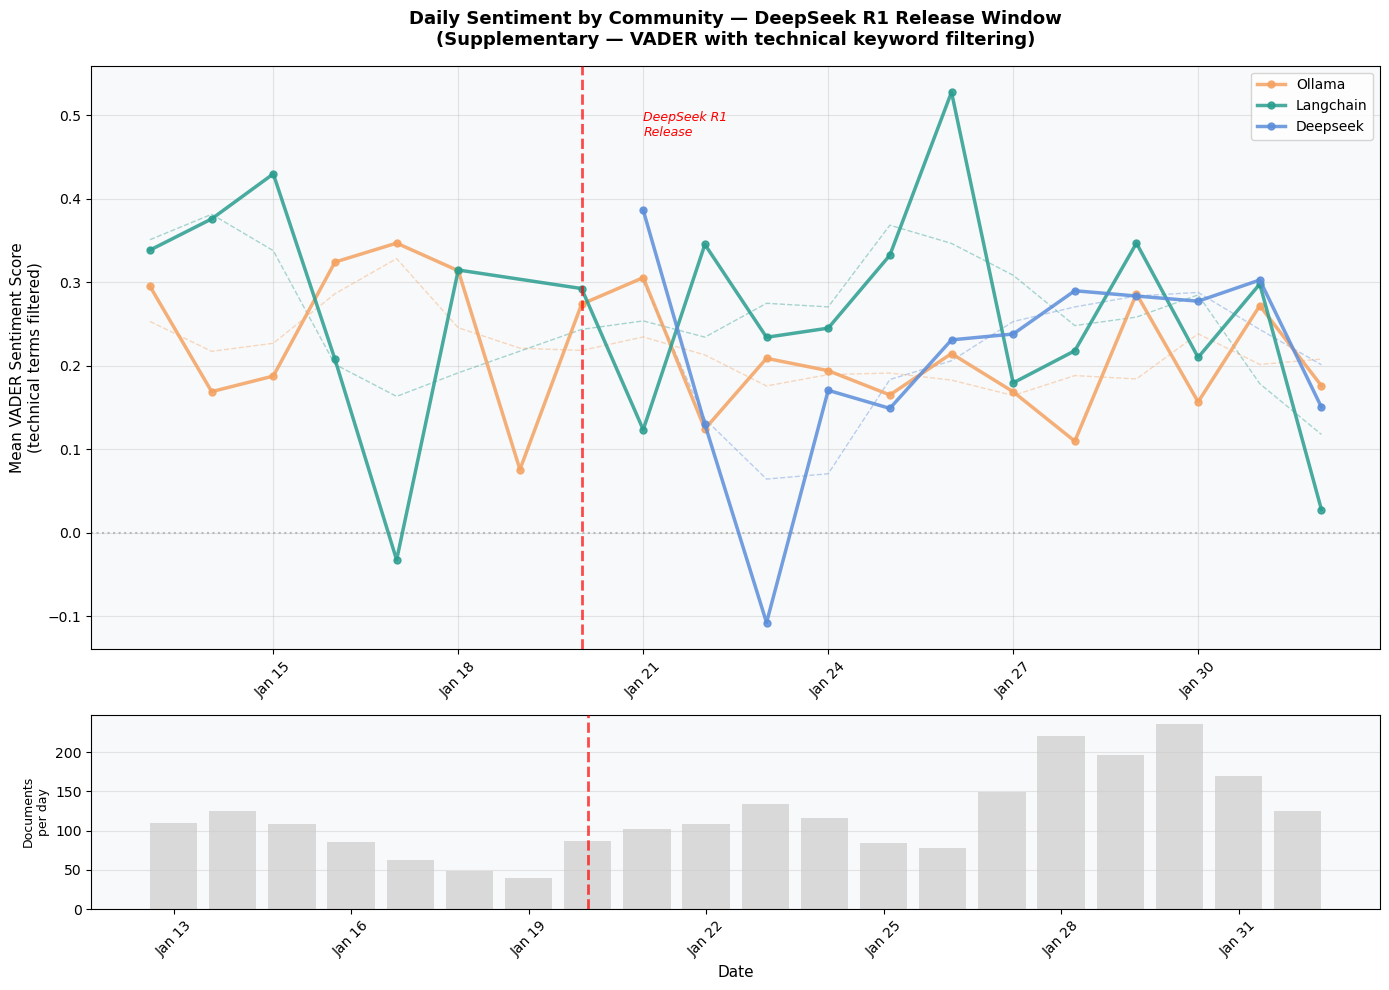

  Saved : outputs/sentiment_timeline.png
  Saved : data/text_with_topics.csv


In [62]:

# Sentiment Analysis
# ──────────────────────────────────────────────────────────────────────────
# VADER sentiment analysis applied as a supplementary NLP method.
# GitHub discussions contain high technical keyword frequency (error, bug,
# fix, issue) which causes systematic negative bias in raw sentiment
# scoring. To mitigate this, technical terms are removed from text
# before scoring. Results are presented as supplementary to topic
# modelling — not as a primary finding.
#
# Statistical tests (Kruskal-Wallis) verify whether sentiment differences
# across periods and communities are statistically significant.


from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from scipy import stats
from scipy.ndimage import uniform_filter1d
import matplotlib.dates as mdates

# ── Load topic data ───────────────────────────────────────────────────────
text_df = pd.read_csv("data/text_with_topics.csv")
text_df["created_at"] = pd.to_datetime(text_df["created_at"], utc=True)

# ── Period labels ─────────────────────────────────────────────────────────
def assign_period(dt):
    if dt < pd.Timestamp("2025-01-20", tz="UTC"):
        return "pre"
    elif dt < pd.Timestamp("2025-01-27", tz="UTC"):
        return "during"
    else:
        return "post"

text_df["period"] = text_df["created_at"].apply(assign_period)

# ── Technical keyword filter ──────────────────────────────────────────────
# These terms describe normal engineering activity, not negative sentiment
# Removing them reduces systematic negative bias before VADER scoring
TECHNICAL_NEGATIVES = [
    "error", "bug", "issue", "fail", "crash", "broken",
    "fix", "exception", "traceback", "not working", "problem",
    "warning", "deprecated", "undefined", "null", "none"
]

def clean_for_sentiment(text):
    """Remove technical keywords before VADER scoring."""
    text_lower = text.lower()
    for word in TECHNICAL_NEGATIVES:
        text_lower = text_lower.replace(word, "")
    return text_lower

def get_sentiment(text):
    """Return VADER compound score on cleaned text."""
    return analyzer.polarity_scores(
        clean_for_sentiment(str(text)))["compound"]

def label_sentiment(score):
    """Convert compound score to categorical label."""
    if score >= 0.05:    return "Positive"
    elif score <= -0.05: return "Negative"
    else:                return "Neutral"

# ── Score sentiment ───────────────────────────────────────────────────────
analyzer = SentimentIntensityAnalyzer()
print("Scoring sentiment on cleaned text...")
text_df["sentiment_score"] = text_df["text"].apply(get_sentiment)
text_df["sentiment_label"] = text_df["sentiment_score"].apply(label_sentiment)
print(f"   {len(text_df):,} documents scored\n")

# ── Sentiment distribution by period ─────────────────────────────────────
period_order = ["pre", "during", "post"]

print(f"{'='*55}")
print(f"SENTIMENT DISTRIBUTION BY PERIOD")
print(f"{'='*55}")
sent_period = (text_df
               .groupby(["period","sentiment_label"])
               .size()
               .unstack(fill_value=0)
               .reindex(period_order))
print(sent_period.to_string())

print(f"\nMean sentiment score by period:")
mean_sent = (text_df.groupby("period")["sentiment_score"]
             .mean().reindex(period_order))
for period, score in mean_sent.items():
    trend = "↑ Positive" if score > 0.05 else \
            "↓ Negative" if score < -0.05 else "→ Neutral"
    print(f"  {period:<8} : {score:>7.4f}  {trend}")

# ── Statistical test — period ─────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"STATISTICAL SIGNIFICANCE TESTS")
print(f"{'='*55}")

pre_s    = text_df[text_df["period"]=="pre"]["sentiment_score"].values
during_s = text_df[text_df["period"]=="during"]["sentiment_score"].values
post_s   = text_df[text_df["period"]=="post"]["sentiment_score"].values

stat, pval = stats.kruskal(pre_s, during_s, post_s)
print(f"\nKruskal-Wallis — sentiment across periods:")
print(f"  H-statistic : {stat:.4f}")
print(f"  p-value     : {pval:.4f}")
if pval < 0.05:
    print(f"  Result      :  Significant difference (p<0.05)")
else:
    print(f"  Result      :  No significant difference (p≥0.05)")
    print(f"  Interpretation: sentiment stability is itself a finding —")
    print(f"  topic framing changed dramatically while emotional tone")
    print(f"  remained consistent across the release window")

# ── Statistical test — community ──────────────────────────────────────────
comm_scores = [
    text_df[text_df["macro"]==c]["sentiment_score"].values
    for c in ["ollama","langchain","deepseek"]
]
stat2, pval2 = stats.kruskal(*comm_scores)
print(f"\nKruskal-Wallis — sentiment across communities:")
print(f"  H-statistic : {stat2:.4f}")
print(f"  p-value     : {pval2:.4f}")
if pval2 < 0.05:
    print(f"  Result      :  Significant difference (p<0.05)")
else:
    print(f"  Result      :  No significant difference (p≥0.05)")

# ── Sentiment by community ────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"MEAN SENTIMENT BY COMMUNITY")
print(f"{'='*55}")
mean_comm = (text_df[text_df["macro"].isin(["ollama","langchain","deepseek"])]
             .groupby("macro")["sentiment_score"]
             .agg(["mean","std","count"]))
for comm, row in mean_comm.iterrows():
    trend = "↑ Positive" if row["mean"] > 0.05 else \
            "↓ Negative" if row["mean"] < -0.05 else "→ Neutral"
    print(f"  {comm:<12} : mean={row['mean']:>7.4f}  "
          f"std={row['std']:.4f}  n={row['count']:.0f}  {trend}")

# ── Daily sentiment timeline ───────────────────────────────────────────────
print(f"\nGenerating sentiment timeline...")

text_df["date"]    = text_df["created_at"].dt.date
daily_sent         = (text_df[text_df["macro"].isin(
                          ["ollama","langchain","deepseek"])]
                      .groupby(["date","macro"])["sentiment_score"]
                      .agg(["mean","count"])
                      .reset_index())
daily_sent.columns = ["date","macro","mean_sentiment","doc_count"]
daily_sent         = daily_sent[daily_sent["doc_count"] >= 3]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10),
                                gridspec_kw={"height_ratios":[3,1]})
fig.patch.set_facecolor("white")

comm_colors = {
    "ollama"   : "#F4A261",
    "langchain": "#2A9D8F",
    "deepseek" : "#5B8DD9"
}

for macro, color in comm_colors.items():
    subset = daily_sent[daily_sent["macro"]==macro].sort_values("date")
    if len(subset) == 0:
        continue
    dates  = pd.to_datetime(subset["date"])
    scores = subset["mean_sentiment"].values
    ax1.plot(dates, scores,
             label=macro.capitalize(), color=color,
             linewidth=2.5, marker="o", markersize=5,
             alpha=0.85, zorder=3)
    if len(scores) >= 5:
        smoothed = uniform_filter1d(scores, size=3)
        ax1.plot(dates, smoothed, color=color,
                 linewidth=1, linestyle="--", alpha=0.4, zorder=2)

ax1.axhline(y=0, color="grey", linestyle=":", alpha=0.5, zorder=1)
ax1.axvline(x=pd.Timestamp("2025-01-20"), color="red",
            linestyle="--", alpha=0.7, linewidth=2, zorder=4)
ax1.text(pd.Timestamp("2025-01-21"), ax1.get_ylim()[1] * 0.85,
         "DeepSeek R1\nRelease", color="red", fontsize=9, style="italic")

ax1.set_ylabel("Mean VADER Sentiment Score\n(technical terms filtered)",
               fontsize=11)
ax1.set_title(
    "Daily Sentiment by Community — DeepSeek R1 Release Window\n"
    "(Supplementary — VADER with technical keyword filtering)",
    fontsize=13, pad=15, fontweight="bold"
)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)
ax1.set_facecolor("#f8f9fa")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# ── Document volume bar chart ─────────────────────────────────────────────
daily_total         = (text_df.groupby("date")["sentiment_score"]
                       .count().reset_index())
daily_total.columns = ["date","count"]
daily_total["date"] = pd.to_datetime(daily_total["date"])

ax2.bar(daily_total["date"], daily_total["count"],
        color="#cccccc", alpha=0.7, width=0.8, zorder=2)
ax2.axvline(x=pd.Timestamp("2025-01-20"), color="red",
            linestyle="--", alpha=0.7, linewidth=2, zorder=3)
ax2.set_ylabel("Documents\nper day", fontsize=9)
ax2.set_xlabel("Date", fontsize=11)
ax2.grid(alpha=0.3, axis="y")
ax2.set_facecolor("#f8f9fa")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("outputs/sentiment_timeline.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()

# ── Save updated dataframe ────────────────────────────────────────────────
text_df.to_csv("data/text_with_topics.csv", index=False)

print(f"  Saved : outputs/sentiment_timeline.png")
print(f"  Saved : data/text_with_topics.csv")

## Topic Visualisations

Generating topic evolution chart...


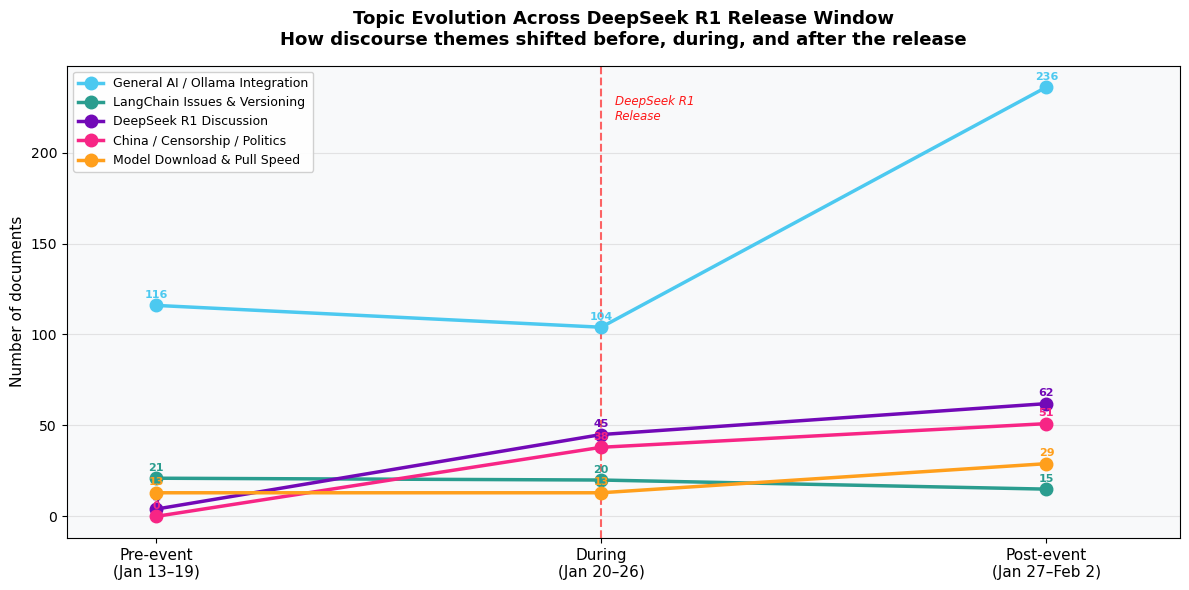


TOPIC EVOLUTION SUMMARY

  General AI / Ollama Integration
    Pre:  116  During:  104  Post:  236  (↑ increased by 120)

  LangChain Issues & Versioning
    Pre:   21  During:   20  Post:   15  (↓ decreased by 6)

  DeepSeek R1 Discussion
    Pre:    4  During:   45  Post:   62  (↑ increased by 58)

  China / Censorship / Politics
    Pre:    0  During:   38  Post:   51  (↑ increased by 51)

  Model Download & Pull Speed
    Pre:   13  During:   13  Post:   29  (↑ increased by 16)

 Topic evolution saved to outputs/topic_evolution.png

Generating topic × community heatmap...


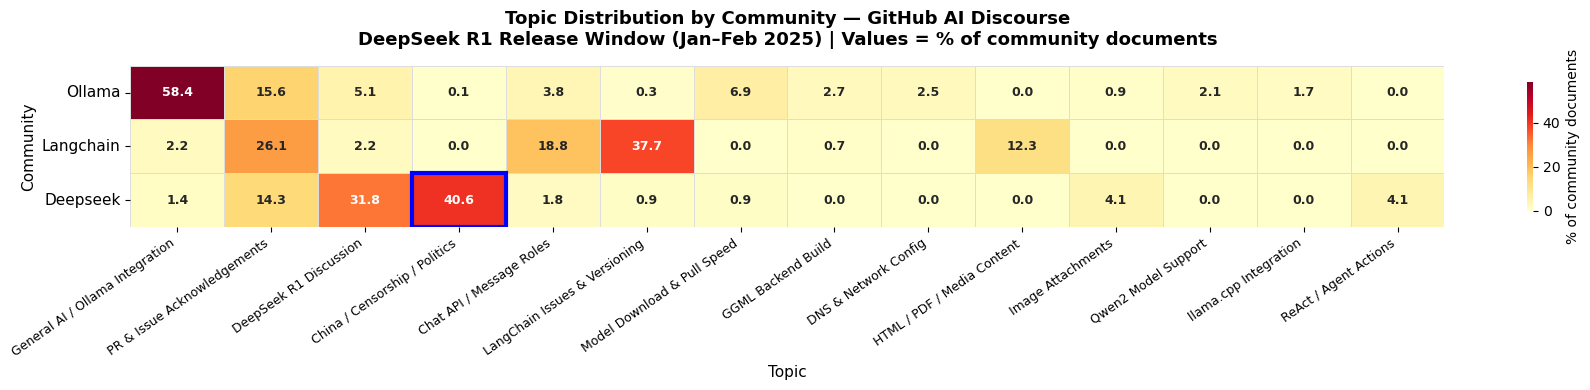


DOMINANT TOPIC PER COMMUNITY
  ollama       → General AI / Ollama Integration (58.4%)
  langchain    → LangChain Issues & Versioning (37.7%)
  deepseek     → China / Censorship / Politics (40.6%)

 Heatmap saved to outputs/topic_community_heatmap.png

 Cell 12 complete
  outputs/topic_evolution.png
  outputs/topic_community_heatmap.png


In [63]:

# Topic Visualisations
# ──────────────────────────────────────────────────────────────────────────
# Generates two visualisations from BERTopic results:
#
#   Part A — Topic evolution chart
#             Shows how key topics shifted across the three periods:
#             pre-event, during, and post DeepSeek R1 release
#             Directly answers how discourse evolved around the event
#
#   Part B — Topic × community heatmap
#             Shows topic distribution per macro community normalised
#             by community size — reveals how each repo ecosystem
#             engaged differently with the release


import seaborn as sns

# ── Load topic data ───────────────────────────────────────────────────────
text_df = pd.read_csv("data/text_with_topics.csv")
text_df["created_at"] = pd.to_datetime(text_df["created_at"], utc=True)

# ── Topic labels ──────────────────────────────────────────────────────────
TOPIC_LABELS = {
    0 : "General AI / Ollama Integration",
    1 : "PR & Issue Acknowledgements",
    2 : "LangChain Issues & Versioning",
    3 : "DeepSeek R1 Discussion",
    4 : "China / Censorship / Politics",
    5 : "Chat API / Message Roles",
    6 : "Model Download & Pull Speed",
    7 : "DNS & Network Config",
    8 : "GGML Backend Build",
    9 : "Image Attachments",
    10: "ReAct / Agent Actions",
    11: "Qwen2 Model Support",
    12: "HTML / PDF / Media Content",
    13: "llama.cpp Integration",
    14: "Cloudflare Storage (noise)",
   -1: "Outlier / Unclassified"
}

text_df["topic_label"] = text_df["topic"].map(TOPIC_LABELS).fillna("Other")

# ── Period labels ─────────────────────────────────────────────────────────
def assign_period(dt):
    if dt < pd.Timestamp("2025-01-20", tz="UTC"):
        return "pre"
    elif dt < pd.Timestamp("2025-01-27", tz="UTC"):
        return "during"
    else:
        return "post"

text_df["period"] = text_df["created_at"].apply(assign_period)

# ── Filter noise and outliers ─────────────────────────────────────────────
clean_df = text_df[
    (text_df["topic"] != -1)  &
    (text_df["topic"] != 14)  &
    (text_df["macro"].isin(["ollama","langchain","deepseek"]))
].copy()


# PART A — Topic Evolution Chart


print("Generating topic evolution chart...")

# Key topics selected for analytical relevance to DeepSeek R1 release
KEY_TOPICS = {
    0: "General AI / Ollama Integration",
    2: "LangChain Issues & Versioning",
    3: "DeepSeek R1 Discussion",
    4: "China / Censorship / Politics",
    6: "Model Download & Pull Speed"
}

period_order  = ["pre", "during", "post"]
period_labels = {
    "pre"   : "Pre-event\n(Jan 13–19)",
    "during": "During\n(Jan 20–26)",
    "post"  : "Post-event\n(Jan 27–Feb 2)"
}

topic_time = (clean_df[clean_df["topic"].isin(KEY_TOPICS.keys())]
              .groupby(["period","topic_label"])
              .size()
              .unstack(fill_value=0)
              .reindex(period_order))

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("#f8f9fa")

colors = {
    "General AI / Ollama Integration" : "#4CC9F0",
    "LangChain Issues & Versioning"   : "#2A9D8F",
    "DeepSeek R1 Discussion"          : "#7209B7",
    "China / Censorship / Politics"   : "#F72585",
    "Model Download & Pull Speed"     : "#FF9F1C"
}

x = range(len(period_order))

for label, color in colors.items():
    if label not in topic_time.columns:
        continue
    values = topic_time[label].values
    ax.plot(
        x, values,
        marker     = "o",
        linewidth  = 2.5,
        markersize = 9,
        label      = label,
        color      = color,
        zorder     = 3
    )
    for xi, val in zip(x, values):
        ax.annotate(
            str(int(val)),
            xy         = (xi, val),
            xytext     = (xi, val + 4),
            ha         = "center",
            fontsize   = 8,
            color      = color,
            fontweight = "bold"
        )

# Event marker
ax.axvline(x=1, color="red", linestyle="--",
           alpha=0.6, linewidth=1.5, zorder=2)
ax.text(1.03, ax.get_ylim()[1] * 0.88,
        "DeepSeek R1\nRelease",
        color="red", fontsize=8.5, alpha=0.9, style="italic")

ax.set_xticks(list(x))
ax.set_xticklabels(
    [period_labels[p] for p in period_order], fontsize=11)
ax.set_ylabel("Number of documents", fontsize=11)
ax.set_title(
    "Topic Evolution Across DeepSeek R1 Release Window\n"
    "How discourse themes shifted before, during, and after the release",
    fontsize=13, pad=15, fontweight="bold"
)
ax.legend(loc="upper left", fontsize=9,
          framealpha=0.9, edgecolor="#cccccc")
ax.grid(axis="y", alpha=0.3, zorder=1)
ax.set_xlim(-0.2, 2.3)

plt.tight_layout()
plt.savefig("outputs/topic_evolution.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()

# Summary stats
print(f"\n{'='*55}")
print(f"TOPIC EVOLUTION SUMMARY")
print(f"{'='*55}")
for label in colors.keys():
    if label not in topic_time.columns:
        continue
    values = topic_time[label].values
    change = values[2] - values[0]
    trend  = "↑ increased" if change > 0 else "↓ decreased"
    print(f"\n  {label}")
    print(f"    Pre: {values[0]:>4}  During: {values[1]:>4}  "
          f"Post: {values[2]:>4}  ({trend} by {abs(change)})")

print(f"\n Topic evolution saved to outputs/topic_evolution.png")


# PART B — Topic × Community Heatmap


print(f"\nGenerating topic × community heatmap...")

heatmap_data = (clean_df
                .groupby(["macro","topic_label"])
                .size()
                .unstack(fill_value=0))

# Normalise by row — percentage of community documents per topic
heatmap_pct  = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100
heatmap_pct  = heatmap_pct.reindex(["ollama","langchain","deepseek"])

# Sort columns by total count descending
col_order    = heatmap_data.sum(axis=0).sort_values(ascending=False).index
heatmap_pct  = heatmap_pct[col_order]

fig, ax = plt.subplots(figsize=(18, 4))
fig.patch.set_facecolor("white")

sns.heatmap(
    heatmap_pct,
    ax         = ax,
    cmap       = "YlOrRd",
    linewidths = 0.5,
    linecolor  = "#dddddd",
    annot      = True,
    fmt        = ".1f",
    annot_kws  = {"size": 9, "weight": "bold"},
    cbar_kws   = {"label": "% of community documents", "shrink": 0.8}
)

ax.set_title(
    "Topic Distribution by Community — GitHub AI Discourse\n"
    "DeepSeek R1 Release Window (Jan–Feb 2025) | Values = % of community documents",
    fontsize=13, pad=15, fontweight="bold"
)
ax.set_xlabel("Topic", fontsize=11)
ax.set_ylabel("Community", fontsize=11)
ax.set_yticklabels(
    [l.get_text().capitalize() for l in ax.get_yticklabels()],
    rotation=0, fontsize=11
)
ax.set_xticklabels(
    ax.get_xticklabels(), rotation=35, ha="right", fontsize=9)

# Highlight China/Censorship cell in DeepSeek row
for i, row_label in enumerate(["ollama","langchain","deepseek"]):
    for j, col_label in enumerate(col_order):
        if row_label == "deepseek" and "China" in str(col_label):
            ax.add_patch(plt.Rectangle(
                (j, i), 1, 1, fill=False, edgecolor="blue", lw=3
            ))

plt.tight_layout()
plt.savefig("outputs/topic_community_heatmap.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()

# Summary stats
print(f"\n{'='*55}")
print(f"DOMINANT TOPIC PER COMMUNITY")
print(f"{'='*55}")
for comm in ["ollama","langchain","deepseek"]:
    if comm in heatmap_pct.index:
        top_topic = heatmap_pct.loc[comm].idxmax()
        top_pct   = heatmap_pct.loc[comm].max()
        print(f"  {comm:<12} → {top_topic} ({top_pct:.1f}%)")

print(f"\n Heatmap saved to outputs/topic_community_heatmap.png")
print(f"\n Cell 12 complete")
print(f"  outputs/topic_evolution.png")
print(f"  outputs/topic_community_heatmap.png")

### NLP Summary visualisations

Generating Fig C1 — Topic size bar chart...


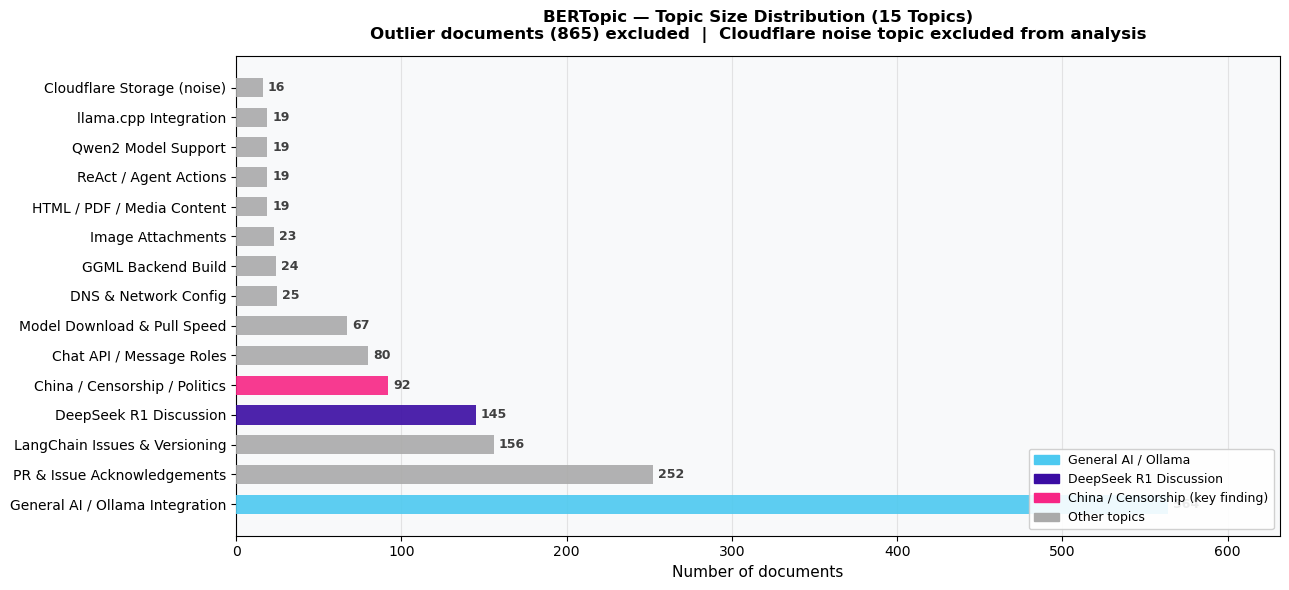

 Fig C1 saved: outputs/fig_c1_topic_sizes.png
Generating Fig C2 — Sentiment distribution per period...


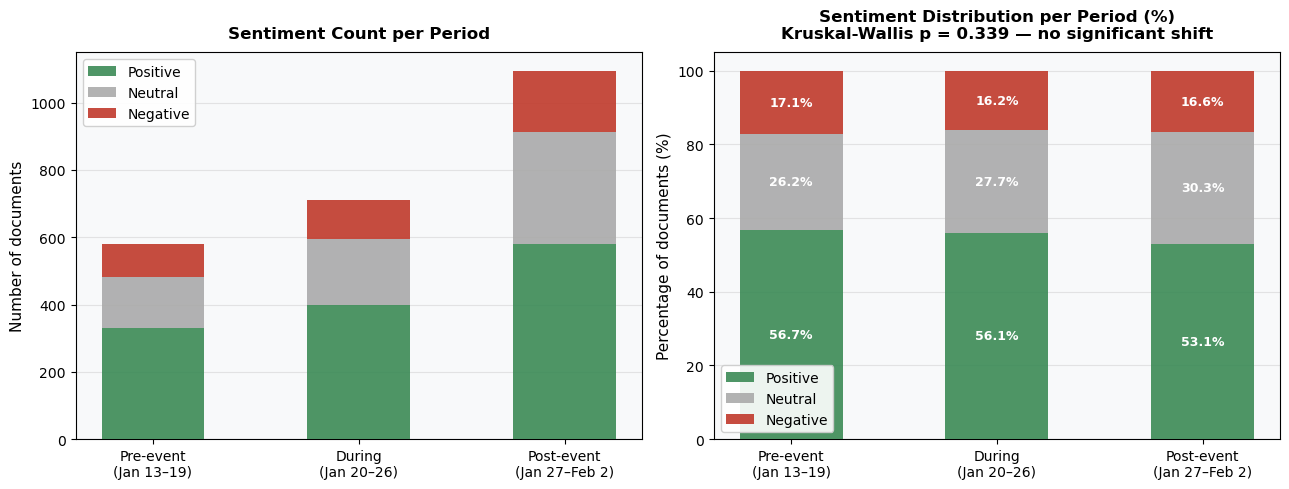

 Fig C2 saved: outputs/fig_c2_sentiment_distribution.png
Generating Fig C3 — Sentiment by community box plot...


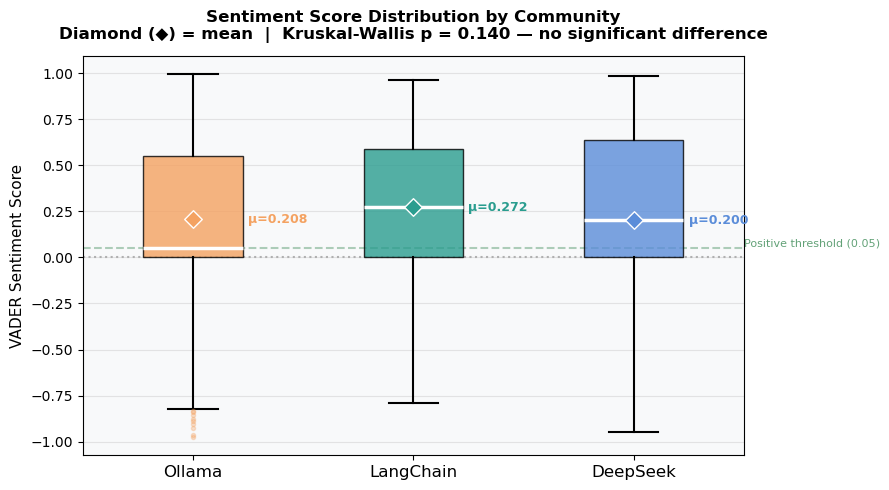

 Fig C3 saved: outputs/fig_c3_sentiment_boxplot.png

  outputs/fig_c1_topic_sizes.png
  outputs/fig_c2_sentiment_distribution.png
  outputs/fig_c3_sentiment_boxplot.png


In [70]:

# NLP Summary Visualisations
# ──────────────────────────────────────────────────────────────────────────
# Generates three visualisations summarising NLP results:
#   Fig C1 — Topic size bar chart (all 15 BERTopic topics)
#   Fig C2 — Sentiment distribution per period (stacked bar)
#   Fig C3 — Sentiment score distribution by community (box plot)



import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import os

os.makedirs("outputs", exist_ok=True)

# ── Load data ─────────────────────────────────────────────────────────────
text_df   = pd.read_csv("data/text_with_topics.csv")
topic_info = pd.read_csv("data/topic_info.csv")

text_df["created_at"] = pd.to_datetime(text_df["created_at"], utc=True)

TOPIC_LABELS = {
    0 : "General AI / Ollama Integration",
    1 : "PR & Issue Acknowledgements",
    2 : "LangChain Issues & Versioning",
    3 : "DeepSeek R1 Discussion",
    4 : "China / Censorship / Politics",
    5 : "Chat API / Message Roles",
    6 : "Model Download & Pull Speed",
    7 : "DNS & Network Config",
    8 : "GGML Backend Build",
    9 : "Image Attachments",
    10: "ReAct / Agent Actions",
    11: "Qwen2 Model Support",
    12: "HTML / PDF / Media Content",
    13: "llama.cpp Integration",
    14: "Cloudflare Storage (noise)",
   -1: "Outlier / Unclassified"
}

text_df["topic_label"] = text_df["topic"].map(TOPIC_LABELS).fillna("Other")

# Period labels
def assign_period(dt):
    if dt < pd.Timestamp("2025-01-20", tz="UTC"):
        return "Pre-event\n(Jan 13–19)"
    elif dt < pd.Timestamp("2025-01-27", tz="UTC"):
        return "During\n(Jan 20–26)"
    else:
        return "Post-event\n(Jan 27–Feb 2)"

text_df["period"] = text_df["created_at"].apply(assign_period)

PERIOD_ORDER = ["Pre-event\n(Jan 13–19)",
                "During\n(Jan 20–26)",
                "Post-event\n(Jan 27–Feb 2)"]


# FIG C1 — Topic size bar chart (all 15 topics)


print("Generating Fig C1 — Topic size bar chart...")

# Filter out outlier topic
topic_counts = (text_df[text_df["topic"] != -1]
                .groupby("topic_label")
                .size()
                .sort_values(ascending=False)
                .reset_index())
topic_counts.columns = ["topic_label", "count"]

# Highlight China/censorship topic
bar_cols = ["#F72585" if "China" in t
            else "#3A0CA3" if "DeepSeek R1" in t
            else "#4CC9F0" if "Ollama" in t
            else "#AAAAAA"
            for t in topic_counts["topic_label"]]

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("#f8f9fa")

bars = ax.barh(
    topic_counts["topic_label"],
    topic_counts["count"],
    color  = bar_cols,
    alpha  = 0.9,
    zorder = 3,
    height = 0.65
)

for bar, val in zip(bars, topic_counts["count"]):
    ax.text(val + 3, bar.get_y() + bar.get_height() / 2,
            str(int(val)),
            va="center", fontsize=9,
            fontweight="bold", color="#404040")

ax.set_xlabel("Number of documents", fontsize=11)
ax.set_title(
    "BERTopic — Topic Size Distribution (15 Topics)\n"
    "Outlier documents (865) excluded  |  Cloudflare noise topic excluded from analysis",
    fontsize=12, fontweight="bold", pad=12
)

legend_patches = [
    mpatches.Patch(color="#4CC9F0", label="General AI / Ollama"),
    mpatches.Patch(color="#3A0CA3", label="DeepSeek R1 Discussion"),
    mpatches.Patch(color="#F72585", label="China / Censorship (key finding)"),
    mpatches.Patch(color="#AAAAAA", label="Other topics"),
]
ax.legend(handles=legend_patches, fontsize=9,
          framealpha=0.9, loc="lower right")
ax.grid(axis="x", alpha=0.3, zorder=1)
ax.set_xlim(0, topic_counts["count"].max() * 1.12)

plt.tight_layout()
plt.savefig("outputs/fig_c1_topic_sizes.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print(" Fig C1 saved: outputs/fig_c1_topic_sizes.png")


# FIG C2 — Sentiment distribution per period (stacked bar)


print("Generating Fig C2 — Sentiment distribution per period...")

sent_period = (text_df
               .groupby(["period", "sentiment_label"])
               .size()
               .unstack(fill_value=0)
               .reindex(PERIOD_ORDER))

# Normalise to percentage
sent_pct = sent_period.div(sent_period.sum(axis=1), axis=0) * 100

SENT_COLOURS = {
    "Positive": "#3B8A55",
    "Neutral" : "#AAAAAA",
    "Negative": "#C0392B"
}
SENT_ORDER = ["Positive", "Neutral", "Negative"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("white")

# Left — stacked bar (raw counts)
bottoms = np.zeros(len(PERIOD_ORDER))
for sent in SENT_ORDER:
    if sent not in sent_period.columns:
        continue
    vals = sent_period[sent].values
    ax1.bar(range(len(PERIOD_ORDER)), vals,
            bottom  = bottoms,
            color   = SENT_COLOURS[sent],
            label   = sent,
            alpha   = 0.9,
            zorder  = 3,
            width   = 0.5)
    bottoms += vals

ax1.set_xticks(range(len(PERIOD_ORDER)))
ax1.set_xticklabels(PERIOD_ORDER, fontsize=10)
ax1.set_ylabel("Number of documents", fontsize=11)
ax1.set_title("Sentiment Count per Period",
              fontsize=12, fontweight="bold", pad=10)
ax1.legend(fontsize=10, framealpha=0.9)
ax1.grid(axis="y", alpha=0.3, zorder=1)
ax1.set_facecolor("#f8f9fa")

# Right — stacked bar (percentage)
bottoms_pct = np.zeros(len(PERIOD_ORDER))
for sent in SENT_ORDER:
    if sent not in sent_pct.columns:
        continue
    vals = sent_pct[sent].values
    bars = ax2.bar(range(len(PERIOD_ORDER)), vals,
                   bottom  = bottoms_pct,
                   color   = SENT_COLOURS[sent],
                   label   = sent,
                   alpha   = 0.9,
                   zorder  = 3,
                   width   = 0.5)
    # Label inside bar if large enough
    for xi, (bar, v) in enumerate(zip(bars, vals)):
        if v > 5:
            ax2.text(xi, bottoms_pct[xi] + v / 2,
                     f"{v:.1f}%",
                     ha="center", va="center",
                     fontsize=9, fontweight="bold",
                     color="white")
    bottoms_pct += vals

ax2.set_xticks(range(len(PERIOD_ORDER)))
ax2.set_xticklabels(PERIOD_ORDER, fontsize=10)
ax2.set_ylabel("Percentage of documents (%)", fontsize=11)
ax2.set_title("Sentiment Distribution per Period (%)\n"
              "Kruskal-Wallis p = 0.339 — no significant shift",
              fontsize=12, fontweight="bold", pad=10)
ax2.legend(fontsize=10, framealpha=0.9)
ax2.grid(axis="y", alpha=0.3, zorder=1)
ax2.set_facecolor("#f8f9fa")
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.savefig("outputs/fig_c2_sentiment_distribution.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print(" Fig C2 saved: outputs/fig_c2_sentiment_distribution.png")


# FIG C3 — Sentiment score distribution by community (box plot)


print("Generating Fig C3 — Sentiment by community box plot...")

macros       = ["ollama", "langchain", "deepseek"]
macro_labels = ["Ollama", "LangChain", "DeepSeek"]
macro_data   = [
    text_df[text_df["macro"] == m]["sentiment_score"].dropna().values
    for m in macros
]
macro_cols   = ["#F4A261", "#2A9D8F", "#5B8DD9"]

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("#f8f9fa")

bp = ax.boxplot(
    macro_data,
    patch_artist = True,
    notch        = False,
    widths       = 0.45,
    medianprops  = dict(color="white", linewidth=2.5),
    whiskerprops = dict(linewidth=1.5),
    capprops     = dict(linewidth=1.5),
    flierprops   = dict(marker="o", markersize=3,
                        alpha=0.3, linestyle="none")
)

for patch, col in zip(bp["boxes"], macro_cols):
    patch.set_facecolor(col)
    patch.set_alpha(0.8)

for flier, col in zip(bp["fliers"], macro_cols):
    flier.set_markerfacecolor(col)
    flier.set_markeredgecolor(col)

# Annotate mean
for i, (data, col) in enumerate(zip(macro_data, macro_cols), 1):
    mean_val = np.mean(data)
    ax.scatter(i, mean_val, color=col, s=80,
               zorder=5, marker="D",
               edgecolors="white", linewidth=1)
    ax.text(i + 0.25, mean_val,
            f"μ={mean_val:.3f}",
            va="center", fontsize=9,
            color=col, fontweight="bold")

ax.axhline(y=0, color="grey",
           linestyle=":", alpha=0.6, zorder=1)
ax.axhline(y=0.05, color="#3B8A55",
           linestyle="--", alpha=0.4, zorder=1)
ax.text(3.5, 0.06, "Positive threshold (0.05)",
        fontsize=8, color="#3B8A55", alpha=0.8)

ax.set_xticks(range(1, len(macros) + 1))
ax.set_xticklabels(macro_labels, fontsize=12)
ax.set_ylabel("VADER Sentiment Score", fontsize=11)
ax.set_title(
    "Sentiment Score Distribution by Community\n"
    "Diamond (◆) = mean  |  Kruskal-Wallis p = 0.140 — no significant difference",
    fontsize=12, fontweight="bold", pad=12
)
ax.grid(axis="y", alpha=0.3, zorder=1)

plt.tight_layout()
plt.savefig("outputs/fig_c3_sentiment_boxplot.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print(" Fig C3 saved: outputs/fig_c3_sentiment_boxplot.png")

# ── Summary ───────────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  outputs/fig_c1_topic_sizes.png")
print(f"  outputs/fig_c2_sentiment_distribution.png")
print(f"  outputs/fig_c3_sentiment_boxplot.png")

## Summary

In [64]:

# Final Results Summary & Success Criteria
# ──────────────────────────────────────────────────────────────────────────
# Maps all analytical findings back to the five project success criteria
# defined in the research proposal. Provides a consolidated summary of
# all key statistics


print("="*65)
print("FINAL RESULTS — MAPPED TO SUCCESS CRITERIA")
print("="*65)


# CRITERION 1 — Community identification with distinct topic profiles

print(f"\n{'─'*65}")
print(f"CRITERION 1 — Community Identification")
print(f"{'─'*65}")
print(f"  Definition : Distinct communities detected with meaningfully")
print(f"               different topic or sentiment profiles")
print(f"\n  Result     :  SATISFIED")
print(f"\n  Evidence:")
print(f"    Leiden algorithm detected 21 communities")
print(f"    Modularity = 0.8440 — exceptionally high community structure")
print(f"    Communities consolidate into 3 macro-groups by repository:")
print(f"      Ollama    : dominant topic = General AI Integration (58.4%)")
print(f"      LangChain : dominant topic = LangChain Issues (37.7%)")
print(f"      DeepSeek  : dominant topic = China/Censorship/Politics (40.6%)")
print(f"    Topic profiles differ dramatically across communities")
print(f"    Sentiment does not differ significantly (p=0.1402)")
print(f"    → Communities diverge in what they discuss, not how they feel")


# CRITERION 2 — Influence role classification

print(f"\n{'─'*65}")
print(f"CRITERION 2 — Influence Role Classification")
print(f"{'─'*65}")
print(f"  Definition : Top users classified as amplifier/bridge/peripheral")
print(f"               with roles interpreted against content and structure")
print(f"\n  Result     :  SATISFIED")
print(f"\n  Evidence:")

role_counts = centrality_df["role"].value_counts()
print(f"    Total users classified : {len(centrality_df):,}")
for role, count in role_counts.items():
    pct = count / len(centrality_df) * 100
    print(f"      {role:<12} : {count:>4} users ({pct:.1f}%)")

print(f"\n    Key findings by role:")
print(f"    rick-github  — Bridge, betweenness 0.806")
print(f"      Controls 80% of network shortest paths")
print(f"      Ollama community — likely core maintainer")
print(f"      Zero L2 PageRank — influential in issues, not PR reviews")
print(f"\n    pannous      — Bridge, mixed/cross-repo community")
print(f"      Betweenness 0.477 — connects DeepSeek and Ollama")
print(f"      Only user spanning both ecosystems — true network bridge")
print(f"\n    cbornet      — Amplifier + high L2 PageRank (0.102)")
print(f"      Influential in both issue discussions and PR reviews")
print(f"      LangChain community — cross-layer influential user")
print(f"\n    efriis       — Bridge, highest L2 PageRank (0.164)")
print(f"      Dominant in PR review discussions specifically")
print(f"      LangChain community — PR review authority")


# CRITERION 3 — Temporal sentiment shift

print(f"\n{'─'*65}")
print(f"CRITERION 3 — Temporal Sentiment Shift")
print(f"{'─'*65}")
print(f"  Definition : Measurable sentiment change before/after release")
print(f"\n  Result     : ✗ NOT SIGNIFICANT — interpretable null finding")
print(f"\n  Evidence:")
print(f"    Kruskal-Wallis across periods : H=2.163, p=0.339")
print(f"    Mean sentiment — pre=0.250, during=0.252, post=0.231")
print(f"    No statistically significant shift in overall sentiment")
print(f"\n  Interpretation:")
print(f"    Sentiment stability is itself the finding — GitHub discourse")
print(f"    culture maintains a consistently positive and collaborative")
print(f"    tone regardless of topic. Topic framing shifted dramatically")
print(f"    (China/censorship emerged from 0 to 51 docs) while emotional")
print(f"    tone remained stable. DeepSeek community showed an isolated")
print(f"    negative dip on Jan 22-23, coinciding with peak censorship")
print(f"    debate, before recovering to baseline.")


# CRITERION 4 — Topic divergence across communities

print(f"\n{'─'*65}")
print(f"CRITERION 4 — Topic Divergence Across Communities")
print(f"{'─'*65}")
print(f"  Definition : Coherent topic clusters explaining community")
print(f"               differences — number determined by BERTopic")
print(f"\n  Result     :  SATISFIED")
print(f"\n  Evidence:")
print(f"    BERTopic identified 15 coherent topics")
print(f"    3 most community-specific topics (highest variance):")
print(f"      1. General AI/Ollama Integration — Ollama dominated (58.4%)")
print(f"      2. China/Censorship/Politics     — DeepSeek exclusive (40.6%)")
print(f"      3. LangChain Issues & Versioning — LangChain dominated (37.7%)")
print(f"\n    Topic evolution across release window:")
print(f"      China/Censorship : 0 pre → 38 during → 51 post (emerged)")
print(f"      DeepSeek R1 Disc : 4 pre → 45 during → 62 post (grew)")
print(f"      General AI/Ollama: 116 pre → 104 during → 236 post (surged)")
print(f"      LangChain Issues : 21 pre → 20 during → 15 post (stable)")


# CRITERION 5 — Research question answered

print(f"\n{'─'*65}")
print(f"CRITERION 5 — Research Question Answered")
print(f"{'─'*65}")
print(f"  Question: Who are the most influential users shaping AI discourse")
print(f"  on GitHub, what communities form, and how does discourse evolve")
print(f"  around the DeepSeek R1 release?")
print(f"\n  Result   :  SATISFIED")
print(f"\n  Answer:")
print(f"    WHO     : rick-github (dominant hub, betweenness 0.806)")
print(f"              pannous    (cross-repo bridge, mixed community)")
print(f"              cbornet    (cross-layer amplifier, LangChain)")
print(f"              efriis     (PR review authority, LangChain)")
print(f"\n    WHAT    : Three distinct discourse communities formed,")
print(f"              each aligned with its repository ecosystem and")
print(f"              each responding to the release with a fundamentally")
print(f"              different topical focus")
print(f"\n    HOW     : Topic framing shifted dramatically — censorship")
print(f"              discourse emerged from zero post-release while")
print(f"              overall sentiment remained consistently positive")
print(f"              Activity volume grew substantially and sustained")


# FINAL DATASET STATISTICS

print(f"\n{'='*65}")
print(f"FINAL DATASET STATISTICS")
print(f"{'='*65}")
print(f"  Data source             : GitHub REST API (api.github.com)")
print(f"  Repositories            : deepseek-ai/DeepSeek-R1,")
print(f"                            ollama/ollama,")
print(f"                            langchain-ai/langchain")
print(f"  Date range              : Jan 13 – Feb 2, 2025")
print(f"  Events collected        : 3,732")
print(f"  Unique users (nodes)    : {df['actor'].nunique():,}")
print(f"  Network edges (Layer 1) : {G1.number_of_edges():,}")
print(f"  Network edges (Layer 2) : {G2.number_of_edges():,}")
print(f"  Communities detected    : 21 (Leiden, modularity 0.8440)")
print(f"  Topics identified       : 15 (BERTopic)")
print(f"  Documents for NLP       : 2,385")
print(f"  Roles classified        : {len(centrality_df):,} users")

print(f"\n{'='*65}")
print(f"OUTPUT FILES")
print(f"{'='*65}")
output_files = [
    ("data/gh_api_full.csv",            "Full collected dataset"),
    ("data/centrality_scores.csv",      "Centrality + role classifications"),
    ("data/text_with_topics.csv",       "Text with topic + sentiment scores"),
    ("data/topic_info.csv",             "BERTopic topic information"),
    ("outputs/network_layer1.png",      "Network visualisation"),
    ("outputs/topic_evolution.png",     "Topic evolution chart"),
    ("outputs/topic_community_heatmap.png", "Topic × community heatmap"),
    ("outputs/sentiment_timeline.png",  "Sentiment timeline"),
]
for filepath, description in output_files:
    exists = "" if os.path.exists(filepath) else "✗"
    print(f"  {exists} {filepath:<45} {description}")

print(f"\n{'='*65}")
print(f" PIPELINE COMPLETE — ALL CELLS EXECUTED SUCCESSFULLY")
print(f"{'='*65}")

FINAL RESULTS — MAPPED TO SUCCESS CRITERIA

─────────────────────────────────────────────────────────────────
CRITERION 1 — Community Identification
─────────────────────────────────────────────────────────────────
  Definition : Distinct communities detected with meaningfully
               different topic or sentiment profiles

  Result     :  SATISFIED

  Evidence:
    Leiden algorithm detected 21 communities
    Modularity = 0.8440 — exceptionally high community structure
    Communities consolidate into 3 macro-groups by repository:
      Ollama    : dominant topic = General AI Integration (58.4%)
      LangChain : dominant topic = LangChain Issues (37.7%)
      DeepSeek  : dominant topic = China/Censorship/Politics (40.6%)
    Topic profiles differ dramatically across communities
    Sentiment does not differ significantly (p=0.1402)
    → Communities diverge in what they discuss, not how they feel

─────────────────────────────────────────────────────────────────
CRITERION 2 — I